# Analysis Notebook

This notebook is the **post-processing and plotting stage** split from `FullEnergyOptimizationDemo11.ipynb`.

## Scope of this notebook
- Read CSV/run artifacts generated by `simulation.ipynb`.
- Compute follow-up metrics.
- Produce summary tables and plots.

## What this notebook avoids
- Running new optimization or Monte Carlo simulation batches.


## Analysis Workflow

Run top-to-bottom in experiment order.

1. Setup imports and shared defaults.
2. Configure and run baseline / Exp1 / Exp2 analysis blocks.
3. Configure and run Exp3a.
4. Configure and run Exp4 family generation, then Exp4 pre-check / Exp4 / Exp4a / Exp4b plots.
5. Configure and run Exp5.
6. Configure and run Exp6a.

Each analysis block has a dataset-selection cell immediately before it.


In [36]:
# Setup imports, repo-path resolution, and deterministic module reload for notebook execution.
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys
import importlib
from pathlib import Path

# Resolve repository root from current notebook location.
repo_root = Path.cwd().resolve()
if not (repo_root / '.git').exists():
    for parent in repo_root.parents:
        if (parent / '.git').exists():
            repo_root = parent
            break

source_dir = repo_root / 'Codes' / 'sourcecode'
source_dir_str = str(source_dir)

# Force this repo's sourcecode to the front to avoid stale/other-path imports.
if source_dir_str in sys.path:
    sys.path.remove(source_dir_str)
sys.path.insert(0, source_dir_str)

import stochastic_baseload_multiple_building_simulation_and_aggregation as sbm
sbm = importlib.reload(sbm)

# Export plotting helpers used by analysis sections.
plot_dwelling_stackplot_from_breakdown = sbm.plot_dwelling_stackplot_from_breakdown
plot_aggregate_stackplot_from_cache = sbm.plot_aggregate_stackplot_from_cache
run_penetration_pixel_convergence_from_cache = sbm.run_penetration_pixel_convergence_from_cache
run_hhp_mhp_ev_penetration_experiment_from_cache = sbm.run_hhp_mhp_ev_penetration_experiment_from_cache
run_hhp_mhp_boiler_penetration_experiment_from_cache = sbm.run_hhp_mhp_boiler_penetration_experiment_from_cache
run_hhp_mhp_boiler_gas_experiment_from_cache = sbm.run_hhp_mhp_boiler_gas_experiment_from_cache


In [37]:
# Common analysis artifact paths generated by simulation.ipynb.
exp_analysis_root = Path(repo_root) / 'Output Data'
exp_penetration_dir = exp_analysis_root / 'Penetration Sweep'

# Baseline outputs: align this with `output_subdir` used in simulation baseline cell.
baseline_output_subdir = 'Test'
baseline_output_dir = exp_analysis_root / baseline_output_subdir
baseline_artifact_dir = baseline_output_dir / 'artifacts'

# Experiment-specific artifact paths.
exp1_manifest_csv = exp_analysis_root / 'Experiment 1 EV Sweep' / 'exp1_run_manifest.csv'
exp2_output_dir = exp_analysis_root / 'Convergence Plot'
exp2_manifest_csv = exp2_output_dir / 'exp2_run_manifest.csv'
exp2_peak_csv = exp2_output_dir / 'hhp_ev5kw_peak_demand_by_run.csv'
exp4_pre_csv = exp_penetration_dir / 'exp4_pre_pixel_convergence.csv'
exp4_result_csv = exp_penetration_dir / 'ev_hhp_penetration_max_demand.csv'
exp4a_result_csv = exp_penetration_dir / 'evconst_hhp_mhp_boiler_penetration_max_demand.csv'
exp4b_result_csv = exp_penetration_dir / 'evconst_hhp_mhp_boiler_annual_gas_co2.csv'

# Tariff timeline assumptions used by analysis-only tariff reconstructions.
analysis_step = '30min'
analysis_n_days = 7

print('Analysis root:', exp_analysis_root)
print('Baseline artifact dir:', baseline_artifact_dir)
print('Experiment 1 manifest exists:', exp1_manifest_csv.exists(), '->', exp1_manifest_csv)
print('Experiment 2 manifest exists:', exp2_manifest_csv.exists(), '->', exp2_manifest_csv)
print('Experiment 4-pre CSV exists:', exp4_pre_csv.exists(), '->', exp4_pre_csv)
print('Experiment 4 table exists:', exp4_result_csv.exists(), '->', exp4_result_csv)
print('Experiment 4a table exists:', exp4a_result_csv.exists(), '->', exp4a_result_csv)
print('Experiment 4b table exists:', exp4b_result_csv.exists(), '->', exp4b_result_csv)


Analysis root: E:\Github\LV-network\Output Data
Baseline artifact dir: E:\Github\LV-network\Output Data\Test\artifacts
Experiment 1 manifest exists: False -> E:\Github\LV-network\Output Data\Experiment 1 EV Sweep\exp1_run_manifest.csv
Experiment 2 manifest exists: False -> E:\Github\LV-network\Output Data\Convergence Plot\exp2_run_manifest.csv
Experiment 4-pre CSV exists: False -> E:\Github\LV-network\Output Data\Penetration Sweep\exp4_pre_pixel_convergence.csv
Experiment 4 table exists: False -> E:\Github\LV-network\Output Data\Penetration Sweep\ev_hhp_penetration_max_demand.csv
Experiment 4a table exists: False -> E:\Github\LV-network\Output Data\Penetration Sweep\evconst_hhp_mhp_boiler_penetration_max_demand.csv
Experiment 4b table exists: False -> E:\Github\LV-network\Output Data\Penetration Sweep\evconst_hhp_mhp_boiler_annual_gas_co2.csv


## Baseline Artifact Check

This section verifies baseline artifacts exported by `simulation.ipynb`.


In [ ]:
# Dataset selection for baseline artifact check.
baseline_output_subdir = 'Test'
baseline_artifact_dir = Path(repo_root) / 'Output Data' / baseline_output_subdir / 'artifacts'
print('Baseline dataset:', baseline_artifact_dir)


In [ ]:
# === Baseline artifact check (from simulation notebook) ===
if not baseline_artifact_dir.exists():
    print('Baseline artifact folder not found:', baseline_artifact_dir)
else:
    print('Baseline artifact folder:', baseline_artifact_dir)
    baseline_csv_files = sorted(baseline_artifact_dir.glob('*.csv'))
    print('CSV files found:', [p.name for p in baseline_csv_files])

    baseline_run_summary_csv = baseline_artifact_dir / 'baseline_run_summary.csv'
    if baseline_run_summary_csv.exists():
        baseline_run_summary_df = pd.read_csv(baseline_run_summary_csv)
        print('Baseline run summary rows:', len(baseline_run_summary_df))
        if 'solve_status' in baseline_run_summary_df.columns:
            print('Solve status counts:')
            print(baseline_run_summary_df['solve_status'].value_counts(dropna=False))
    else:
        print('Missing:', baseline_run_summary_csv)

    baseline_profile_usage_csv = baseline_artifact_dir / 'baseline_profile_usage.csv'
    if baseline_profile_usage_csv.exists():
        baseline_profile_usage_df = pd.read_csv(baseline_profile_usage_csv)
        print('Baseline profile usage rows:', len(baseline_profile_usage_df))
        display(baseline_profile_usage_df.head(10))
    else:
        print('Missing:', baseline_profile_usage_csv)


## Experiment 1 Analysis

Plot EV sweep peak-demand and feasibility trends from simulation-generated manifest CSV.


In [ ]:
# Dataset selection for Experiment 1 analysis.
exp1_manifest_csv = Path(repo_root) / 'Output Data' / 'Experiment 1 EV Sweep' / 'exp1_run_manifest.csv'
print('Experiment 1 manifest:', exp1_manifest_csv)


In [ ]:
# === Experiment 1 analysis: EV sweep peak-demand and feasibility trends ===
if not exp1_manifest_csv.exists():
    raise FileNotFoundError('Run simulation notebook Experiment 1 first. Missing: ' + str(exp1_manifest_csv))

exp1_manifest_df = pd.read_csv(exp1_manifest_csv)
if exp1_manifest_df.empty:
    raise ValueError('Experiment 1 manifest is empty: ' + str(exp1_manifest_csv))

def _exp1_parse_status_counts(raw_value):
    if isinstance(raw_value, dict):
        return raw_value
    if pd.isna(raw_value):
        return {}
    try:
        parsed = ast.literal_eval(str(raw_value))
        if isinstance(parsed, dict):
            return parsed
    except Exception:
        pass
    return {}

exp1_manifest_df['optimal_runs'] = exp1_manifest_df['status_counts'].apply(
    lambda x: int(_exp1_parse_status_counts(x).get('optimal', 0))
)
exp1_manifest_df['infeasible_runs'] = exp1_manifest_df['status_counts'].apply(
    lambda x: int(_exp1_parse_status_counts(x).get('infeasible', 0))
)

exp1_mc_runs_num = pd.to_numeric(exp1_manifest_df['mc_runs'], errors='coerce').fillna(0.0).to_numpy(dtype=float)
exp1_opt_runs_num = pd.to_numeric(exp1_manifest_df['optimal_runs'], errors='coerce').fillna(0.0).to_numpy(dtype=float)
exp1_manifest_df['optimal_rate_pct'] = np.where(exp1_mc_runs_num > 0, 100.0 * exp1_opt_runs_num / exp1_mc_runs_num, np.nan)

display(
    exp1_manifest_df[
        [
            'case_label',
            'ev_charge_max_kw',
            'mc_runs',
            'optimal_runs',
            'infeasible_runs',
            'optimal_rate_pct',
            'mean_peak_kw',
            'p95_peak_kw',
            'max_peak_kw',
            'output_dir',
        ]
    ].sort_values(['case_label', 'ev_charge_max_kw'])
)

exp1_plot_output_dir = exp_analysis_root / 'plots'
exp1_plot_output_dir.mkdir(parents=True, exist_ok=True)

fig, (ax_peak, ax_feas) = plt.subplots(2, 1, figsize=(9, 8), sharex=True)
for exp1_case_label, exp1_case_df in exp1_manifest_df.groupby('case_label'):
    exp1_case_df = exp1_case_df.sort_values('ev_charge_max_kw')

    ax_peak.plot(
        exp1_case_df['ev_charge_max_kw'],
        exp1_case_df['mean_peak_kw'],
        marker='o',
        linewidth=1.7,
        label=f"{exp1_case_label} mean peak",
    )
    ax_peak.plot(
        exp1_case_df['ev_charge_max_kw'],
        exp1_case_df['p95_peak_kw'],
        marker='s',
        linewidth=1.4,
        linestyle='--',
        label=f"{exp1_case_label} P95 peak",
    )

    ax_feas.plot(
        exp1_case_df['ev_charge_max_kw'],
        exp1_case_df['optimal_rate_pct'],
        marker='o',
        linewidth=1.7,
        label=str(exp1_case_label),
    )

ax_peak.set_ylabel('Peak demand (kW)')
ax_peak.set_title('Experiment 1: Peak-demand trend vs EV charger power')
ax_peak.grid(True, alpha=0.3)
ax_peak.legend(loc='best')

ax_feas.set_xlabel('EV charge limit (kW)')
ax_feas.set_ylabel('Optimal-run share (%)')
ax_feas.set_title('Experiment 1: Feasibility trend vs EV charger power')
ax_feas.grid(True, alpha=0.3)
ax_feas.legend(loc='best')

fig.tight_layout()
exp1_plot_path = exp1_plot_output_dir / 'exp1_ev_sweep_peak_and_feasibility.png'
fig.savefig(exp1_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print('Saved Experiment 1 analysis plot to:', exp1_plot_path)


## Experiment 2 Analysis

Compute run-wise peak-demand statistics from saved `mc_run_*.csv` files and plot histogram/convergence.


In [ ]:
# Dataset selection for Experiment 2 analysis.
exp2_output_dir = Path(repo_root) / 'Output Data' / 'Convergence Plot'
exp2_manifest_csv = exp2_output_dir / 'exp2_run_manifest.csv'
exp2_peak_csv = exp2_output_dir / 'hhp_ev5kw_peak_demand_by_run.csv'
print('Experiment 2 dataset dir:', exp2_output_dir)


In [ ]:
# === Experiment 2 analysis: histogram + convergence from saved run CSVs ===
if not exp2_output_dir.exists():
    raise FileNotFoundError('Run simulation notebook Experiment 2 first. Missing directory: ' + str(exp2_output_dir))

def _exp2_run_number_from_path(path_obj: Path) -> int:
    try:
        return int(path_obj.stem.split('_')[-1])
    except Exception:
        return -1

exp2_run_files = sorted(exp2_output_dir.glob('mc_run_*.csv'), key=_exp2_run_number_from_path)
if not exp2_run_files:
    raise FileNotFoundError('No Experiment 2 run CSV files found in: ' + str(exp2_output_dir))

exp2_peak_rows = []
for exp2_run_path in exp2_run_files:
    exp2_run_no = _exp2_run_number_from_path(exp2_run_path)
    exp2_run_df = pd.read_csv(exp2_run_path)
    exp2_elec_cols = [c for c in exp2_run_df.columns if c.startswith('elec_kw_')]
    if not exp2_elec_cols:
        raise ValueError('No electricity columns found in ' + str(exp2_run_path))

    exp2_peak_rows.append(
        {
            'run': int(exp2_run_no),
            'peak_electricity_kw': float(exp2_run_df[exp2_elec_cols].sum(axis=1).max()),
            'source_file': str(exp2_run_path),
        }
    )

exp2_peak_summary_df = pd.DataFrame(exp2_peak_rows)
exp2_peak_summary_df = exp2_peak_summary_df.sort_values('run').drop_duplicates(subset=['run'], keep='last').reset_index(drop=True)
exp2_peak_summary_df['cumulative_avg_peak_kw'] = exp2_peak_summary_df['peak_electricity_kw'].expanding().mean()

exp2_peak_summary_df.to_csv(exp2_peak_csv, index=False)
print('Saved Experiment 2 peak summary CSV to:', exp2_peak_csv)

hist_path = exp2_output_dir / 'hhp_ev5kw_peak_demand_histogram.png'
fig_hist, ax_hist = plt.subplots(figsize=(8, 5))
exp2_peak_values = exp2_peak_summary_df['peak_electricity_kw'].to_numpy(dtype=float)
ax_hist.hist(
    exp2_peak_values,
    bins=max(10, int(np.sqrt(len(exp2_peak_values)))),
    color='tab:blue',
    edgecolor='white',
    alpha=0.85,
)
ax_hist.set_title('HHP (EV 5 kW): Histogram of Run-wise Peak Electricity Demand')
ax_hist.set_xlabel('Peak aggregated electricity demand (kW)')
ax_hist.set_ylabel('Number of runs')
ax_hist.grid(True, alpha=0.3)
fig_hist.tight_layout()
fig_hist.savefig(hist_path, dpi=300, bbox_inches='tight')
plt.show()

conv_path = exp2_output_dir / 'hhp_ev5kw_peak_demand_convergence.png'
fig_conv, ax_conv = plt.subplots(figsize=(8, 5))
exp2_run_numbers = exp2_peak_summary_df['run'].to_numpy(dtype=int)
exp2_cum_avg = exp2_peak_summary_df['cumulative_avg_peak_kw'].to_numpy(dtype=float)
ax_conv.plot(exp2_run_numbers, exp2_cum_avg, color='tab:orange', linewidth=1.8, label='Cumulative average')
ax_conv.axhline(
    exp2_cum_avg[-1],
    color='k',
    linestyle='--',
    linewidth=1.2,
    label=f"Final mean = {exp2_cum_avg[-1]:.3f} kW",
)
ax_conv.set_title('HHP (EV 5 kW): Convergence of Average Peak Demand')
ax_conv.set_xlabel('Run number')
ax_conv.set_ylabel('Cumulative average peak demand (kW)')
ax_conv.grid(True, alpha=0.3)
ax_conv.legend(loc='best')
fig_conv.tight_layout()
fig_conv.savefig(conv_path, dpi=300, bbox_inches='tight')
plt.show()

if exp2_manifest_csv.exists():
    exp2_manifest_df = pd.read_csv(exp2_manifest_csv)
    display(exp2_manifest_df)

print('Saved histogram to:', hist_path)
print('Saved convergence plot to:', conv_path)


## Experiment 3a Analysis

Aggregate cached per-dwelling breakdown outputs and plot stacked demand curves by case.
This section uses existing cached run folders and does not launch new optimization runs.


In [ ]:
# Dataset selection for Experiment 3a analysis.
# Option A (auto-discovery): set exp3a_case_dirs = None and provide exp3a_dataset_root.
exp3a_dataset_root = Path(repo_root) / 'Output Data' / 'Single Dwelling Runs' / 'randomized offset'
exp3a_case_dirs = None
# Option B (manual explicit cases):
# exp3a_case_dirs = {
#     'case_label_a': Path(repo_root) / 'Output Data' / 'Single Dwelling Runs' / 'your_case_folder_a',
#     'case_label_b': Path(repo_root) / 'Output Data' / 'Single Dwelling Runs' / 'your_case_folder_b',
# }
exp3a_plot_output_root = Path(repo_root) / 'Output Data' / 'plots'
exp3a_only_optimal = False
exp3a_envelope_mode = 'extreme'  # 'percentile' or 'extreme'
exp3a_envelope_low_pct = 10.0
exp3a_envelope_high_pct = 90.0
exp3a_max_dwellings = None
print('Experiment 3a dataset root:', exp3a_dataset_root)


In [ ]:
# === Experiment 3a: Aggregate demand curves from Experiment 3 breakdowns ===
# Specify case folders from Experiment 3 outputs and compare aggregated demand breakdowns.

import re

# Dataset/config is taken from the previous configuration cell.
exp3a_randomized_offset_root = Path(exp3a_dataset_root)
exp3a_plot_output_root = Path(exp3a_plot_output_root)
exp3a_plot_output_root.mkdir(parents=True, exist_ok=True)

# Optional explicit case map (dict[label -> path]); if None, auto-discover from dataset root.
if exp3a_case_dirs is None:
    exp3a_case_dirs = {}
    if exp3a_randomized_offset_root.exists():
        for p in sorted(exp3a_randomized_offset_root.iterdir()):
            if p.is_dir() and p.name.lower() != 'plots':
                exp3a_case_dirs[p.name] = p

if not exp3a_case_dirs:
    raise FileNotFoundError('No case folders found under ' + str(exp3a_randomized_offset_root))

exp3a_only_optimal = bool(exp3a_only_optimal)
exp3a_envelope_mode = str(exp3a_envelope_mode).strip().lower()
if exp3a_envelope_mode not in {'percentile', 'extreme'}:
    raise ValueError("exp3a_envelope_mode must be 'percentile' or 'extreme'.")

# Load all per-dwelling breakdown CSVs for one case and align common run IDs.
def _exp3a_load_case_aggregate(case_dir, only_optimal=False, max_dwellings=None):
    case_dir = Path(case_dir)
    files = sorted(case_dir.glob('dwelling_*_runs_breakdown.csv'))
    if max_dwellings is not None:
        files = files[:int(max_dwellings)]
    if not files:
        raise FileNotFoundError('No breakdown files found in ' + str(case_dir))

    common_runs = None
    time_index = None
    parsed = []

    # Parse each dwelling file into per-run component arrays.
    for file_path in files:
        df = pd.read_csv(file_path)
        if only_optimal and 'solve_status' in df.columns:
            df = df[df['solve_status'].astype(str).str.lower() == 'optimal']
        if df.empty:
            continue

        required = {'time', 'run', 'hp_elec_kw', 'ev_charge_kw', 'appliance_kw'}
        missing = required - set(df.columns)
        if missing:
            raise ValueError('Missing columns in ' + str(file_path) + ': ' + str(sorted(missing)))

        df['time'] = pd.to_datetime(df['time'], errors='coerce')
        df = df.dropna(subset=['time'])
        run_ids = sorted(df['run'].unique())
        if not run_ids:
            continue

        run_frames = []
        run_set = set()
        local_time = None
        n_steps = None
        for r in run_ids:
            rdf = df[df['run'] == r].sort_values('time')
            if local_time is None:
                local_time = pd.DatetimeIndex(rdf['time'])
                n_steps = len(local_time)
            elif len(rdf) != n_steps:
                continue
            run_set.add(int(r))
            run_frames.append((
                int(r),
                rdf['hp_elec_kw'].to_numpy(dtype=float),
                rdf['ev_charge_kw'].to_numpy(dtype=float),
                rdf['appliance_kw'].to_numpy(dtype=float),
            ))

        if not run_frames:
            continue

        if time_index is None:
            time_index = local_time
        elif not local_time.equals(time_index):
            raise ValueError('Time index mismatch in ' + str(file_path))

        common_runs = run_set if common_runs is None else (common_runs & run_set)
        parsed.append((file_path, run_frames))

    if time_index is None or not parsed:
        raise ValueError('No valid breakdown data available in ' + str(case_dir))
    if not common_runs:
        raise ValueError('No common run IDs across dwellings in ' + str(case_dir))

    # Keep only run IDs available for every dwelling before aggregation.
    common_runs = sorted(common_runs)
    sum_hp = np.zeros((len(common_runs), len(time_index)), dtype=float)
    sum_ev = np.zeros_like(sum_hp)
    sum_app = np.zeros_like(sum_hp)

    for _, run_frames in parsed:
        run_map = {r: (hp, ev, app) for (r, hp, ev, app) in run_frames}
        for i, r in enumerate(common_runs):
            hp, ev, app = run_map[r]
            sum_hp[i, :] += hp
            sum_ev[i, :] += ev
            sum_app[i, :] += app

    return {
        'time_index': time_index,
        'hp_runs': sum_hp,
        'ev_runs': sum_ev,
        'app_runs': sum_app,
        'n_dwellings': len(parsed),
        'n_common_runs': len(common_runs),
    }

# Aggregate and prepare each requested case.
exp3a_results = []
for exp3a_case, exp3a_dir in exp3a_case_dirs.items():
    case_data = _exp3a_load_case_aggregate(
        exp3a_dir,
        only_optimal=exp3a_only_optimal,
        max_dwellings=exp3a_max_dwellings,
    )
    exp3a_results.append((exp3a_case, Path(exp3a_dir), case_data))

if not exp3a_results:
    raise ValueError('No cases loaded for Experiment 3a.')

# Build original cozy/agile tariffs aligned to Experiment 3a timeline.
exp3a_time_index_ref = exp3a_results[0][2]['time_index']
exp3a_cozy_tariff = sbm.build_tariff(
    exp3a_time_index_ref[0],
    n_days=analysis_n_days,
    step=analysis_step,
    type='cozy',
)
exp3a_agile_tariff = sbm.build_tariff(
    exp3a_time_index_ref[0],
    n_days=analysis_n_days,
    step=analysis_step,
    type='agile',
)
if not exp3a_cozy_tariff.index.equals(exp3a_time_index_ref):
    exp3a_cozy_tariff = exp3a_cozy_tariff.reindex(exp3a_time_index_ref, method='ffill')
if not exp3a_agile_tariff.index.equals(exp3a_time_index_ref):
    exp3a_agile_tariff = exp3a_agile_tariff.reindex(exp3a_time_index_ref, method='ffill')

# Collect switch timestamps from both tariffs to align all subplots.
def _exp3a_extract_switch_times(tariff_df):
    elec_vals = tariff_df['elec_price'].to_numpy()
    gas_vals = tariff_df['gas_price'].to_numpy()
    switch_mask = np.zeros_like(elec_vals, dtype=bool)
    switch_mask[1:] = (elec_vals[1:] != elec_vals[:-1]) | (gas_vals[1:] != gas_vals[:-1])
    return tariff_df.index[switch_mask]

exp3a_switch_times_cozy = _exp3a_extract_switch_times(exp3a_cozy_tariff)
exp3a_switch_times_agile = _exp3a_extract_switch_times(exp3a_agile_tariff)
exp3a_switch_times_all = pd.DatetimeIndex(
    sorted(set(exp3a_switch_times_cozy.tolist()) | set(exp3a_switch_times_agile.tolist()))
)

n_cases = len(exp3a_results)
fig, axes = plt.subplots(
    n_cases + 2,
    1,
    figsize=(10, 3.8 * n_cases + 3.6),
    sharex=True,
    gridspec_kw={'height_ratios': [3.0] * n_cases + [1.2, 1.2]},
)

if n_cases == 1:
    demand_axes = [axes[0]]
else:
    demand_axes = list(axes[:-2])

cozy_tariff_ax = axes[-2]
agile_tariff_ax = axes[-1]
summary_rows = []

for ax, (case_name, case_dir, case_data) in zip(demand_axes, exp3a_results):
    hp_mean = case_data['hp_runs'].mean(axis=0)
    ev_mean = case_data['ev_runs'].mean(axis=0)
    app_mean = case_data['app_runs'].mean(axis=0)
    total_mean = hp_mean + ev_mean + app_mean
    total_runs = case_data['hp_runs'] + case_data['ev_runs'] + case_data['app_runs']

    mode = str(exp3a_envelope_mode).strip().lower()
    if mode == 'extreme':
        low_curve = total_runs.min(axis=0)
        high_curve = total_runs.max(axis=0)
        low_label, high_label = 'Lower extreme', 'Upper extreme'
    else:
        low_curve = np.percentile(total_runs, float(exp3a_envelope_low_pct), axis=0)
        high_curve = np.percentile(total_runs, float(exp3a_envelope_high_pct), axis=0)
        low_label = f"P{exp3a_envelope_low_pct:g}"
        high_label = f"P{exp3a_envelope_high_pct:g}"

    ax.stackplot(
        case_data['time_index'],
        app_mean,
        hp_mean,
        ev_mean,
        labels=['Appliance', 'Heat pump', 'EV'],
        colors=['#B39DDB', '#F6D365', '#90CAF9'],
        alpha=0.65,
        linewidth=0,
        edgecolor='none',
    )
    ax.plot(case_data['time_index'], total_mean, color='white', linewidth=1.2, label='Total (mean)', zorder=5)
    ax.plot(case_data['time_index'], low_curve, color='tab:red', linewidth=1.0, linestyle='--', label=low_label)
    ax.plot(case_data['time_index'], high_curve, color='tab:green', linewidth=1.0, linestyle='--', label=high_label)

    # Draw shared tariff switch lines for visual alignment.
    for ts in exp3a_switch_times_all:
        ax.axvline(ts, color='k', linestyle=':', linewidth=0.9, alpha=0.35)

    ax.set_ylabel('Power (kW)')
    ax.set_title(
        f"{case_name}: aggregated demand breakdown "
        f"({case_data['n_dwellings']} dwellings, {case_data['n_common_runs']} common runs)"
    )
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=3, loc='upper right')

    summary_rows.append(
        {
            'case': case_name,
            'case_dir': str(case_dir),
            'dwellings_used': case_data['n_dwellings'],
            'common_runs': case_data['n_common_runs'],
        }
    )

# Add cozy tariff subplot.
cozy_tariff_ax.step(
    exp3a_cozy_tariff.index,
    exp3a_cozy_tariff['elec_price'],
    where='post',
    label='Electricity price (p/kWh)',
)
cozy_tariff_ax.step(
    exp3a_cozy_tariff.index,
    exp3a_cozy_tariff['gas_price'],
    where='post',
    label='Gas price (p/kWh)',
)
for ts in exp3a_switch_times_all:
    cozy_tariff_ax.axvline(ts, color='k', linestyle=':', linewidth=0.9, alpha=0.35)

cozy_tariff_ax.set_ylabel('Tariff (p/kWh)')
cozy_tariff_ax.set_title('Original cozy tariff')
cozy_tariff_ax.grid(True, alpha=0.3)
cozy_tariff_ax.legend(loc='upper right')

# Add agile tariff subplot.
agile_tariff_ax.step(
    exp3a_agile_tariff.index,
    exp3a_agile_tariff['elec_price'],
    where='post',
    label='Electricity price (p/kWh)',
)
agile_tariff_ax.step(
    exp3a_agile_tariff.index,
    exp3a_agile_tariff['gas_price'],
    where='post',
    label='Gas price (p/kWh)',
)
for ts in exp3a_switch_times_all:
    agile_tariff_ax.axvline(ts, color='k', linestyle=':', linewidth=0.9, alpha=0.35)

agile_tariff_ax.set_ylabel('Tariff (p/kWh)')
agile_tariff_ax.set_title('Original agile tariff')
agile_tariff_ax.grid(True, alpha=0.3)
agile_tariff_ax.legend(loc='upper right')

axes[-1].set_xlabel('Time')
fig.tight_layout()

# Save combined Experiment 3a figure to Output Data/plots with scenario/case/plot-type naming.
exp3a_scenario_tag = re.sub(r'[^A-Za-z0-9]+', '_', exp3a_randomized_offset_root.name).strip('_').lower()
exp3a_case_types = []
for case_name, _, _ in exp3a_results:
    m = re.search(r'(hybrid|monovalent)', str(case_name).lower())
    exp3a_case_types.append(m.group(1) if m else 'unknown')
exp3a_case_tag = '_'.join(sorted(set(exp3a_case_types))) if exp3a_case_types else 'unknown'
exp3a_plot_type_tag = 'stacked_demand_with_tariffs'
exp3a_plot_filename = (
    f"exp3a_scenario_{exp3a_scenario_tag}_cases_{exp3a_case_tag}_{len(exp3a_results)}cases_"
    f"plot_{exp3a_plot_type_tag}.png"
)
exp3a_plot_path = exp3a_plot_output_root / exp3a_plot_filename
fig.savefig(exp3a_plot_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved Experiment 3a plot to: {exp3a_plot_path}")

exp3a_summary_df = pd.DataFrame(summary_rows)
display(exp3a_summary_df)


## Experiment 4 Family (Cache-Based Generation)

This section uses existing per-dwelling breakdown runs to generate:
- Experiment 4 pre-check convergence CSV,
- Experiment 4 penetration sweep CSV,
- Experiment 4a fixed-EV HHP/MHP/boiler sweep CSV,
- Experiment 4b annual gas/CO2 HHP/MHP/boiler sweep CSV.


In [38]:
# Dataset selection for Experiment 4-family cache generation.
exp_penetration_dir = Path(repo_root) / 'Output Data' / 'Penetration Sweep'
exp4_hybrid_cache_dir = (
    Path(repo_root) / 'Output Data' / 'Single Dwelling Runs' / 'randomized offset' / 'agile_hybrid_EV_5kW_offset2p0h'
)
exp4_monovalent_cache_dir = (
    Path(repo_root) / 'Output Data' / 'Single Dwelling Runs' / 'randomized offset' / 'agile_monovalent_EV_5kW_offset2p0h'
)
exp4a_boiler_cache_dir = (
    Path(repo_root) / 'Output Data' / 'Single Dwelling Runs' / 'randomized offset' / 'agile_boiler_only_EV_5kW_offset2p0h'
)

exp4_pre_csv = exp_penetration_dir / 'exp4_pre_pixel_convergence.csv'
exp4_result_csv = exp_penetration_dir / 'ev_hhp_penetration_max_demand.csv'
exp4a_result_csv = exp_penetration_dir / 'evconst_hhp_mhp_boiler_penetration_max_demand.csv'
exp4b_result_csv = exp_penetration_dir / 'evconst_hhp_mhp_boiler_annual_gas_co2.csv'

exp4_use_generated_ev_profiles = False
exp4_ev_gen_params = {}

# Experiment 4 pre-check configuration.
exp4_pre_ev_penetration = 0.4
exp4_pre_hhp_percentage = 0.6
exp4_pre_mc_runs = 500
exp4_pre_random_seed = 42
exp4_pre_show_progress = True

# Experiment 4 sweep configuration.
exp4_ev_penetrations = np.arange(0.0, 1.01, 0.05)
exp4_hhp_percentages = np.arange(0.0, 1.01, 0.05)
exp4_mc_runs_per_pixel = 500
exp4_random_seed = 42
exp4_show_progress = True

# Experiment 4a sweep configuration.
exp4a_ev_penetration = 0.1
exp4a_hhp_percentages = np.arange(0.0, 1.01, 0.05)
exp4a_mhp_percentages = np.arange(0.0, 1.01, 0.05)
exp4a_mc_runs_per_pixel = 500
exp4a_random_seed = 42
exp4a_show_progress = True

# Experiment 4b annual gas / CO2 configuration.
exp4b_hybrid_cache_dir = (
    Path(repo_root) / 'Output Data' / 'Single Dwelling Runs' / 'all-year' / 'Upper-Relaxed' / 'agile_hybrid_EV_0kW_offset2p0h'
)
exp4b_boiler_cache_dir = (
    Path(repo_root) / 'Output Data' / 'Single Dwelling Runs' / 'all-year' / 'Upper-Relaxed' / 'agile_boiler_only_EV_0kW_offset2p0h'
)
exp4b_ev_penetration = 0.0
exp4b_hhp_percentages = np.arange(0.0, 1.01, 0.05)
exp4b_mhp_percentages = np.arange(0.0, 1.01, 0.05)
exp4b_mc_runs_per_pixel = 100
exp4b_random_seed = 42
exp4b_co2_kg_per_kwh = 0.183
exp4b_show_progress = True

# Normalize paths and ensure the output directory exists for the run cells below.
exp4_hybrid_cache_dir = Path(exp4_hybrid_cache_dir)
exp4_monovalent_cache_dir = Path(exp4_monovalent_cache_dir)
exp4a_boiler_cache_dir = Path(exp4a_boiler_cache_dir)
exp4b_hybrid_cache_dir = Path(exp4b_hybrid_cache_dir)
exp4b_boiler_cache_dir = Path(exp4b_boiler_cache_dir)
exp_penetration_dir = Path(exp_penetration_dir)
exp4_pre_csv = Path(exp4_pre_csv)
exp4_result_csv = Path(exp4_result_csv)
exp4a_result_csv = Path(exp4a_result_csv)
exp4b_result_csv = Path(exp4b_result_csv)

exp_penetration_dir.mkdir(parents=True, exist_ok=True)

print('Experiment 4 hybrid cache:', exp4_hybrid_cache_dir)
print('Experiment 4 monovalent cache:', exp4_monovalent_cache_dir)
print('Experiment 4a boiler cache:', exp4a_boiler_cache_dir)
print('Experiment 4b hybrid gas cache:', exp4b_hybrid_cache_dir)
print('Experiment 4b boiler gas cache:', exp4b_boiler_cache_dir)


Experiment 4 hybrid cache: E:\Github\LV-network\Output Data\Single Dwelling Runs\randomized offset\agile_hybrid_EV_5kW_offset2p0h
Experiment 4 monovalent cache: E:\Github\LV-network\Output Data\Single Dwelling Runs\randomized offset\agile_monovalent_EV_5kW_offset2p0h
Experiment 4a boiler cache: E:\Github\LV-network\Output Data\Single Dwelling Runs\randomized offset\agile_boiler_only_EV_5kW_offset2p0h
Experiment 4b hybrid gas cache: E:\Github\LV-network\Output Data\Single Dwelling Runs\all-year\Upper-Relaxed\agile_hybrid_EV_0kW_offset2p0h
Experiment 4b boiler gas cache: E:\Github\LV-network\Output Data\Single Dwelling Runs\all-year\Upper-Relaxed\agile_boiler_only_EV_0kW_offset2p0h


In [ ]:
# === Experiment 4 pre-check: cache-based table generation from existing runs ===
# This step does not run new dwelling-level optimizations; it only mixes cached outputs.

exp4_pre_df = run_penetration_pixel_convergence_from_cache(
    hybrid_cache_dir=exp4_hybrid_cache_dir,
    monovalent_cache_dir=exp4_monovalent_cache_dir,
    ev_penetration=exp4_pre_ev_penetration,
    hhp_percentage=exp4_pre_hhp_percentage,
    mc_runs=exp4_pre_mc_runs,
    random_seed=exp4_pre_random_seed,
    use_generated_ev_profiles=bool(exp4_use_generated_ev_profiles),
    ev_gen_params=exp4_ev_gen_params,
    show_progress=exp4_pre_show_progress,
)
exp4_pre_df.to_csv(exp4_pre_csv, index=False)

print('Saved Experiment 4 pre-check CSV:', exp4_pre_csv)
display(exp4_pre_df.head(10))


In [ ]:
# === Experiment 4: cache-based table generation from existing runs ===
# This step does not run new dwelling-level optimizations; it only mixes cached outputs.

exp4_results = run_hhp_mhp_ev_penetration_experiment_from_cache(
    hybrid_cache_dir=exp4_hybrid_cache_dir,
    monovalent_cache_dir=exp4_monovalent_cache_dir,
    ev_penetrations=exp4_ev_penetrations,
    hhp_percentages=exp4_hhp_percentages,
    mc_runs_per_pixel=exp4_mc_runs_per_pixel,
    random_seed=exp4_random_seed,
    save_path=exp4_result_csv,
    use_generated_ev_profiles=bool(exp4_use_generated_ev_profiles),
    ev_gen_params=exp4_ev_gen_params,
    show_progress=exp4_show_progress,
)

print('Saved Experiment 4 table CSV:', exp4_result_csv, 'rows=', len(exp4_results))
display(exp4_results.head(10))


In [ ]:
# === Experiment 4a: cache-based table generation from existing runs ===
# This step does not run new dwelling-level optimizations; it only mixes cached outputs.

exp4a_results = run_hhp_mhp_boiler_penetration_experiment_from_cache(
    hybrid_cache_dir=exp4_hybrid_cache_dir,
    monovalent_cache_dir=exp4_monovalent_cache_dir,
    boiler_cache_dir=exp4a_boiler_cache_dir,
    ev_penetration=exp4a_ev_penetration,
    hhp_percentages=exp4a_hhp_percentages,
    mhp_percentages=exp4a_mhp_percentages,
    mc_runs_per_pixel=exp4a_mc_runs_per_pixel,
    random_seed=exp4a_random_seed,
    save_path=exp4a_result_csv,
    use_generated_ev_profiles=bool(exp4_use_generated_ev_profiles),
    ev_gen_params=exp4_ev_gen_params,
    show_progress=exp4a_show_progress,
)

print(
    'Saved Experiment 4a table CSV:',
    exp4a_result_csv,
    'rows=',
    len(exp4a_results),
    'valid=',
    int(exp4a_results['valid_mix'].sum()),
)
display(exp4a_results.head(10))


In [39]:
# === Experiment 4b: cache-based annual gas / CO2 table generation from existing runs ===
# This step does not run new dwelling-level optimizations; it only mixes cached outputs.

exp4b_results = run_hhp_mhp_boiler_gas_experiment_from_cache(
    hybrid_cache_dir=exp4b_hybrid_cache_dir,
    boiler_cache_dir=exp4b_boiler_cache_dir,
    ev_penetration=exp4b_ev_penetration,
    hhp_percentages=exp4b_hhp_percentages,
    mhp_percentages=exp4b_mhp_percentages,
    mc_runs_per_pixel=exp4b_mc_runs_per_pixel,
    random_seed=exp4b_random_seed,
    save_path=exp4b_result_csv,
    co2_kg_per_kwh=exp4b_co2_kg_per_kwh,
    show_progress=exp4b_show_progress,
)

print(
    'Saved Experiment 4b gas / CO2 table CSV:',
    exp4b_result_csv,
    'rows=',
    len(exp4b_results),
    'valid=',
    int(exp4b_results['valid_mix'].sum()),
)
display(exp4b_results.head(10))


Penetration pixels (4b gas):   0%|          | 0/231 [00:00<?, ?it/s]

Saved Experiment 4b gas / CO2 table CSV: E:\Github\LV-network\Output Data\Penetration Sweep\evconst_hhp_mhp_boiler_annual_gas_co2.csv rows= 231 valid= 231


,ev_penetration,hhp_percentage,mhp_percentage,boiler_percentage,valid_mix,n_dwellings,n_ev_homes,n_hhp_homes,n_mhp_homes,n_boiler_homes,...,annual_gas_p95_kwh,annual_gas_max_kwh,annual_gas_min_kwh,annual_co2_mean_kg,annual_co2_std_kg,annual_co2_p50_kg,annual_co2_p90_kg,annual_co2_p95_kg,annual_co2_max_kg,annual_co2_min_kg
0,0.0,0.0,0.00,1.00,True,147,0,0,0,147,...,1.602324e+06,1.603697e+06,1.599285e+06,292997.633189,132.244425,292996.824816,293146.315899,293225.223668,293476.619692,292669.132461
1,0.0,0.0,0.05,0.95,True,147,0,0,7,140,...,1.542930e+06,1.549864e+06,1.481846e+06,278821.315890,2518.183485,279084.777967,281815.676561,282356.127561,283625.113347,271177.744100
2,0.0,0.0,0.10,0.90,True,147,0,0,15,132,...,1.461678e+06,1.474036e+06,1.351752e+06,261976.833109,3888.012400,262312.259750,266654.543834,267487.063728,269748.560918,247370.562272
3,0.0,0.0,0.15,0.85,True,147,0,0,22,125,...,1.387730e+06,1.404715e+06,1.285256e+06,248568.117200,3954.672150,248581.738980,253006.210205,253954.609461,257062.818266,235201.915023
4,0.0,0.0,0.20,0.80,True,147,0,0,29,118,...,1.325662e+06,1.336081e+06,1.199108e+06,235303.141351,4923.101703,235550.057110,241542.397697,242596.189207,244502.733376,219436.739020
5,0.0,0.0,0.25,0.75,True,147,0,0,37,110,...,1.245384e+06,1.275063e+06,1.126024e+06,219563.357861,4994.293577,219636.918687,226185.546807,227905.221108,233336.445054,206062.465937
6,0.0,0.0,0.30,0.70,True,147,0,0,44,103,...,1.172118e+06,1.206706e+06,1.034635e+06,204863.501442,5892.113442,205102.622763,212793.153481,214497.599247,220827.241212,189338.139112
7,0.0,0.0,0.35,0.65,True,147,0,0,51,96,...,1.084576e+06,1.095143e+06,9.747078e+05,191390.955051,4763.890630,191978.410299,197010.037978,198477.430508,200411.185532,178371.522460
8,0.0,0.0,0.40,0.60,True,147,0,0,59,88,...,1.017892e+06,1.039446e+06,8.659855e+05,175626.432662,5745.551386,174576.477488,183776.710138,186274.240506,190218.660424,158475.353963
9,0.0,0.0,0.45,0.55,True,147,0,0,66,81,...,9.406644e+05,9.491356e+05,7.768889e+05,161547.542996,6415.979324,161788.304718,169921.021586,172141.588600,173691.812971,142170.663344


## Experiment 4 Pre-Check Analysis

Plot single-pixel convergence from the saved pre-check CSV.


In [ ]:
# Dataset selection for Experiment 4 pre-check plotting.
exp4_pre_csv = Path(repo_root) / 'Output Data' / 'Penetration Sweep' / 'exp4_pre_pixel_convergence.csv'
exp4_pre_plot_path = Path(repo_root) / 'Output Data' / 'Penetration Sweep' / 'exp4_pre_pixel_convergence.png'
print('Experiment 4 pre-check CSV:', exp4_pre_csv)


In [ ]:
# === Experiment 4 pre-check analysis: pixel convergence plot ===
if not exp4_pre_csv.exists():
    raise FileNotFoundError('Run the Experiment 4 family cache-generation cell in this notebook first. Missing: ' + str(exp4_pre_csv))

exp4_pre_df = pd.read_csv(exp4_pre_csv)
required_cols = {'run', 'peak_kw', 'running_mean_kw'}
missing_cols = required_cols - set(exp4_pre_df.columns)
if missing_cols:
    raise ValueError('Missing columns in exp4_pre CSV: ' + str(sorted(missing_cols)))

display(exp4_pre_df.head(20))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(exp4_pre_df['run'], exp4_pre_df['running_mean_kw'], color='tab:blue', linewidth=2.0, label='Running mean peak')
ax.scatter(exp4_pre_df['run'], exp4_pre_df['peak_kw'], color='tab:gray', s=10, alpha=0.35, label='Run-wise peak')
ax.set_xlabel('Run count')
ax.set_ylabel('Peak demand (kW)')
ax.set_title('Experiment 4 pre-check: single-pixel convergence')
ax.grid(True, alpha=0.3)
ax.legend(loc='best')

exp4_pre_plot_path = Path(exp4_pre_plot_path)
fig.tight_layout()
fig.savefig(exp4_pre_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print('Saved Experiment 4 pre-check plot to:', exp4_pre_plot_path)


## Experiment 4 Analysis (From Saved CSV)

Load `ev_hhp_penetration_max_demand.csv` and produce pivot tables + contour plots.


In [ ]:
# Dataset selection for Experiment 4 contour plotting.
exp4_result_csv = Path(repo_root) / 'Output Data' / 'Penetration Sweep' / 'ev_hhp_penetration_max_demand.csv'
exp4_contour_metric = 'max_demand_max_kw'  # max_demand_mean_kw | max_demand_p95_kw | max_demand_max_kw
exp4_contour_png = Path(repo_root) / 'Output Data' / 'Penetration Sweep' / 'ev_hhp_penetration_contour_max_demand.png'
print('Experiment 4 table CSV:', exp4_result_csv)


In [ ]:
# === Experiment 4 analysis: contour from saved table ===
if not exp4_result_csv.exists():
    raise FileNotFoundError('Run the Experiment 4 family cache-generation cell in this notebook first. Missing: ' + str(exp4_result_csv))

exp4_results = pd.read_csv(exp4_result_csv)

display(
    exp4_results[
        [
            'ev_penetration',
            'hhp_percentage',
            'mc_runs_per_pixel',
            'max_demand_mean_kw',
            'max_demand_p95_kw',
            'max_demand_max_kw',
        ]
    ].head(20)
)

exp4_max_table = exp4_results.pivot(index='hhp_percentage', columns='ev_penetration', values='max_demand_max_kw')
exp4_mean_table = exp4_results.pivot(index='hhp_percentage', columns='ev_penetration', values='max_demand_mean_kw')

print('Maximum of MC maxima (kW) by pixel:')
display(exp4_max_table)
print('Mean maximum demand across MC runs (kW) by pixel:')
display(exp4_mean_table)

exp4_contour_metric = str(exp4_contour_metric).strip()
exp4_surface = (
    exp4_results
    .pivot(index='hhp_percentage', columns='ev_penetration', values=exp4_contour_metric)
    .sort_index()
    .sort_index(axis=1)
)

x_vals = exp4_surface.columns.to_numpy(dtype=float) * 100.0
y_vals = exp4_surface.index.to_numpy(dtype=float) * 100.0
X, Y = np.meshgrid(x_vals, y_vals)
Z = exp4_surface.to_numpy(dtype=float)

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
ax.tick_params(axis='both', colors='black')
for spine in ax.spines.values():
    spine.set_color('black')
contour_filled = ax.contourf(X, Y, Z, levels=20, cmap='viridis')
contour_lines = ax.contour(X, Y, Z, levels=10, colors='k', linewidths=0.5, alpha=0.6)
ax.clabel(contour_lines, inline=True, fontsize=8, fmt='%.1f')
ax.set_xlabel('EV penetration (%)', color='black')
ax.set_ylabel('HHP share (%)', color='black')
ax.set_title('2D contour: Maximum demand vs EV penetration and HHP share', color='black')
cbar = fig.colorbar(contour_filled, ax=ax)
cbar.set_label('Maximum demand (kW)', color='black')
cbar.ax.tick_params(colors='black')
cbar.outline.set_edgecolor('black')

exp4_contour_png = Path(exp4_contour_png)
fig.tight_layout()
fig.savefig(exp4_contour_png, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='white')
plt.show()

print(f"Saved contour plot to: {exp4_contour_png}")


## Experiment 4a Analysis (From Saved CSV)

Load fixed-EV penetration sweep table and render the HHP (y) x MHP (x) contour.


In [ ]:
# Dataset selection for Experiment 4a contour plotting.
exp4a_result_csv = Path(repo_root) / 'Output Data' / 'Penetration Sweep' / 'evconst_hhp_mhp_boiler_penetration_max_demand.csv'
exp4a_contour_metric = 'max_demand_max_kw'  # max_demand_mean_kw | max_demand_p95_kw | max_demand_max_kw
exp4a_contour_png = Path(repo_root) / 'Output Data' / 'Penetration Sweep' / 'evconst_hhp_mhp_boiler_penetration_contour_max_demand.png'
print('Experiment 4a table CSV:', exp4a_result_csv)


In [ ]:
# === Experiment 4a analysis: contour from saved table ===
if not exp4a_result_csv.exists():
    raise FileNotFoundError('Run the Experiment 4 family cache-generation cell in this notebook first. Missing: ' + str(exp4a_result_csv))

exp4a_results = pd.read_csv(exp4a_result_csv)
exp4a_valid = exp4a_results[exp4a_results['valid_mix']].copy()
if exp4a_valid.empty:
    raise ValueError('No valid Experiment 4a pixels found (need HHP + MHP <= 100%).')

display(
    exp4a_valid[
        [
            'ev_penetration',
            'hhp_percentage',
            'mhp_percentage',
            'boiler_percentage',
            'valid_mix',
            'max_demand_mean_kw',
            'max_demand_p95_kw',
            'max_demand_max_kw',
        ]
    ].head(20)
)

exp4a_contour_metric = str(exp4a_contour_metric).strip()
exp4a_surface = (
    exp4a_valid
    .pivot(index='hhp_percentage', columns='mhp_percentage', values=exp4a_contour_metric)
    .sort_index()
    .sort_index(axis=1)
)

x_vals = exp4a_surface.columns.to_numpy(dtype=float) * 100.0
y_vals = exp4a_surface.index.to_numpy(dtype=float) * 100.0
X, Y = np.meshgrid(x_vals, y_vals)
Z = np.ma.masked_invalid(exp4a_surface.to_numpy(dtype=float))
exp4a_ev_pct = float(exp4a_valid['ev_penetration'].iloc[0]) * 100.0

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
ax.tick_params(axis='both', colors='black')
for spine in ax.spines.values():
    spine.set_color('black')
contour_filled = ax.contourf(X, Y, Z, levels=20, cmap='viridis')
contour_lines = ax.contour(X, Y, Z, levels=10, colors='k', linewidths=0.5, alpha=0.6)
ax.clabel(contour_lines, inline=True, fontsize=8, fmt='%.1f')
ax.set_xlabel('MHP penetration (%)', color='black')
ax.set_ylabel('HHP penetration (%)', color='black')
ax.set_title(
    f'2D contour: Maximum demand vs HHP and MHP shares (EV fixed at {exp4a_ev_pct:.0f}%)',
    color='black',
)
cbar = fig.colorbar(contour_filled, ax=ax)
cbar.set_label('Maximum demand (kW)', color='black')
cbar.ax.tick_params(colors='black')
cbar.outline.set_edgecolor('black')

exp4a_contour_png = Path(exp4a_contour_png)
fig.tight_layout()
fig.savefig(exp4a_contour_png, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='white')
plt.show()

print(f"Saved Experiment 4a contour plot to: {exp4a_contour_png}")


## Experiment 4b Analysis (From Saved CSV)

Load annual gas / CO2 sweep table and render the HHP (y) x MHP (x) contour.


In [42]:
# Dataset selection for Experiment 4b contour plotting.
exp4b_result_csv = Path(repo_root) / 'Output Data' / 'Penetration Sweep' / 'evconst_hhp_mhp_boiler_annual_gas_co2.csv'
exp4b_gas_contour_metric = 'annual_gas_mean_kwh'  # annual_gas_mean_kwh | annual_gas_p95_kwh | annual_gas_max_kwh
exp4b_co2_contour_metric = 'annual_co2_mean_kg'  # annual_co2_mean_kg | annual_co2_p95_kg | annual_co2_max_kg
exp4b_gas_contour_png = Path(repo_root) / 'Output Data' / 'Penetration Sweep' / 'evconst_hhp_mhp_boiler_contour_annual_gas.png'
exp4b_co2_contour_png = Path(repo_root) / 'Output Data' / 'Penetration Sweep' / 'evconst_hhp_mhp_boiler_contour_annual_co2.png'
exp4b_contour_cmap = 'YlOrRd'
print('Experiment 4b table CSV:', exp4b_result_csv)


Experiment 4b table CSV: E:\Github\LV-network\Output Data\Penetration Sweep\evconst_hhp_mhp_boiler_annual_gas_co2.csv


,ev_penetration,hhp_percentage,mhp_percentage,boiler_percentage,annual_gas_mean_kwh,annual_gas_p95_kwh,annual_co2_mean_kg,annual_co2_p95_kg
0,0.0,0.0,0.00,1.00,1.601080e+06,1.602324e+06,292997.633189,293225.223668
1,0.0,0.0,0.05,0.95,1.523614e+06,1.542930e+06,278821.315890,282356.127561
2,0.0,0.0,0.10,0.90,1.431567e+06,1.461678e+06,261976.833109,267487.063728
3,0.0,0.0,0.15,0.85,1.358296e+06,1.387730e+06,248568.117200,253954.609461
4,0.0,0.0,0.20,0.80,1.285810e+06,1.325662e+06,235303.141351,242596.189207
5,0.0,0.0,0.25,0.75,1.199800e+06,1.245384e+06,219563.357861,227905.221108
6,0.0,0.0,0.30,0.70,1.119473e+06,1.172118e+06,204863.501442,214497.599247
7,0.0,0.0,0.35,0.65,1.045852e+06,1.084576e+06,191390.955051,198477.430508
8,0.0,0.0,0.40,0.60,9.597073e+05,1.017892e+06,175626.432662,186274.240506
9,0.0,0.0,0.45,0.55,8.827735e+05,9.406644e+05,161547.542996,172141.588600


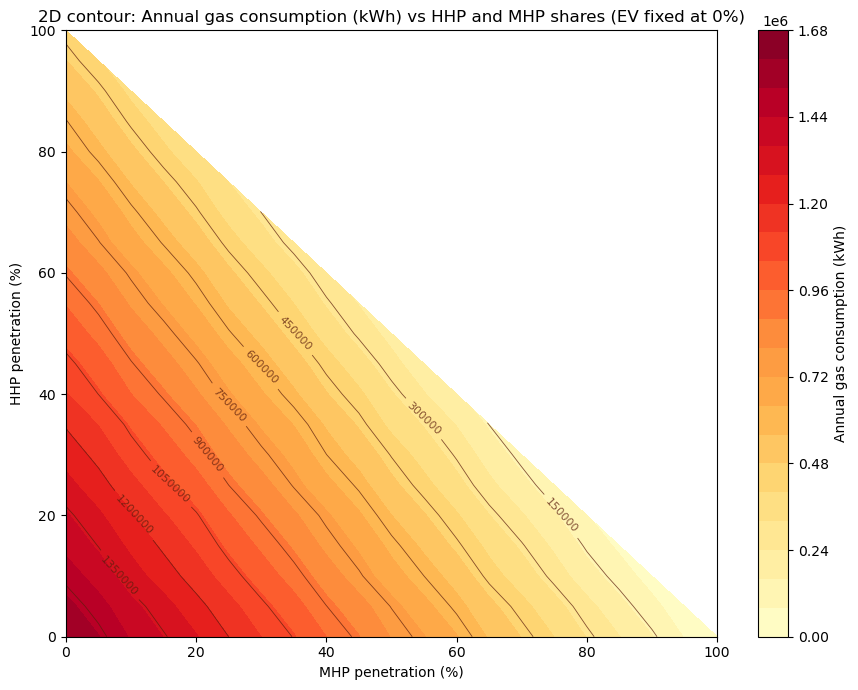

Saved Experiment 4b contour plot to: E:\Github\LV-network\Output Data\Penetration Sweep\evconst_hhp_mhp_boiler_contour_annual_gas.png


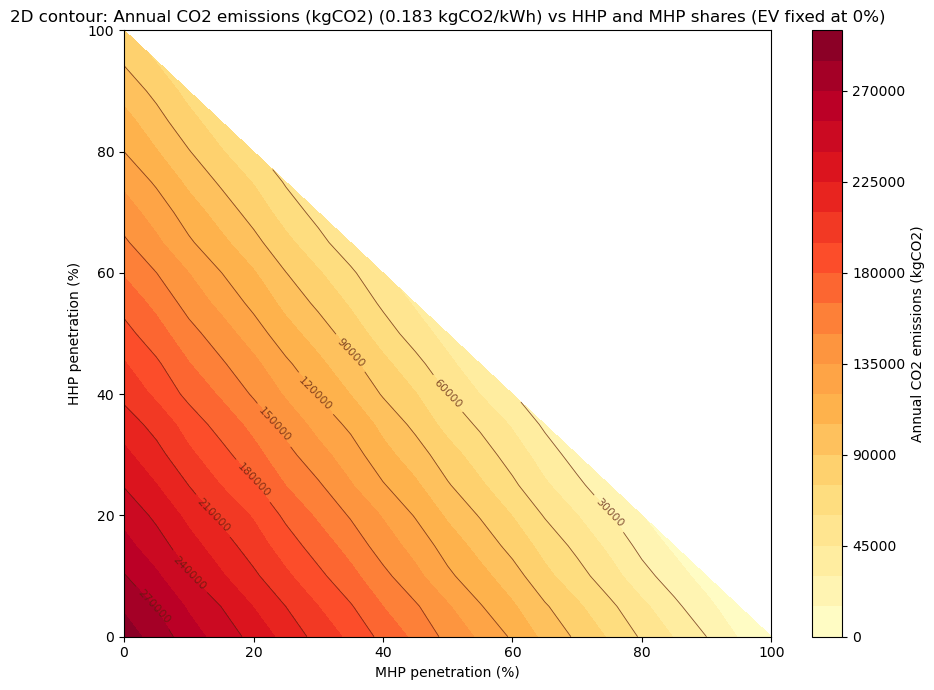

Saved Experiment 4b contour plot to: E:\Github\LV-network\Output Data\Penetration Sweep\evconst_hhp_mhp_boiler_contour_annual_co2.png


In [43]:
# === Experiment 4b analysis: contour from saved annual gas / CO2 table ===
if not exp4b_result_csv.exists():
    raise FileNotFoundError('Run the Experiment 4b cache-generation cell in this notebook first. Missing: ' + str(exp4b_result_csv))

exp4b_results = pd.read_csv(exp4b_result_csv)
exp4b_valid = exp4b_results[exp4b_results['valid_mix']].copy()
if exp4b_valid.empty:
    raise ValueError('No valid Experiment 4b pixels found (need HHP + MHP <= 100%).')

display(
    exp4b_valid[
        [
            'ev_penetration',
            'hhp_percentage',
            'mhp_percentage',
            'boiler_percentage',
            'annual_gas_mean_kwh',
            'annual_gas_p95_kwh',
            'annual_co2_mean_kg',
            'annual_co2_p95_kg',
        ]
    ].head(20)
)

exp4b_co2_factor = float(exp4b_valid['co2_kg_per_kwh'].iloc[0]) if 'co2_kg_per_kwh' in exp4b_valid.columns else 0.183
exp4b_metric_labels = {
    'annual_gas_mean_kwh': 'Annual gas consumption (kWh)',
    'annual_gas_p95_kwh': 'Annual gas consumption p95 (kWh)',
    'annual_gas_max_kwh': 'Annual gas consumption max (kWh)',
    'annual_co2_mean_kg': 'Annual CO2 emissions (kgCO2)',
    'annual_co2_p95_kg': 'Annual CO2 emissions p95 (kgCO2)',
    'annual_co2_max_kg': 'Annual CO2 emissions max (kgCO2)',
}
exp4b_plot_specs = [
    (str(exp4b_gas_contour_metric).strip(), Path(exp4b_gas_contour_png)),
    (str(exp4b_co2_contour_metric).strip(), Path(exp4b_co2_contour_png)),
]

def _exp4b_plot_contour(metric_name, output_path):
    metric_label = exp4b_metric_labels.get(metric_name, metric_name)
    title_label = metric_label
    if '_co2_' in metric_name:
        title_label = f"{metric_label} ({exp4b_co2_factor:.3f} kgCO2/kWh)"

    surface = (
        exp4b_valid
        .pivot(index='hhp_percentage', columns='mhp_percentage', values=metric_name)
        .sort_index()
        .sort_index(axis=1)
    )

    x_vals = surface.columns.to_numpy(dtype=float) * 100.0
    y_vals = surface.index.to_numpy(dtype=float) * 100.0
    X, Y = np.meshgrid(x_vals, y_vals)
    Z = np.ma.masked_invalid(surface.to_numpy(dtype=float))
    ev_pct = float(exp4b_valid['ev_penetration'].iloc[0]) * 100.0
    label_fmt = '%.0f' if ('_kg' in metric_name or '_kwh' in metric_name) else '%.1f'

    fig, ax = plt.subplots(figsize=(9, 7))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    ax.tick_params(axis='both', colors='black')
    for spine in ax.spines.values():
        spine.set_color('black')
    contour_filled = ax.contourf(X, Y, Z, levels=20, cmap=exp4b_contour_cmap)
    contour_lines = ax.contour(X, Y, Z, levels=10, colors='#5c1d0c', linewidths=0.6, alpha=0.75)
    ax.clabel(contour_lines, inline=True, fontsize=8, fmt=label_fmt)
    ax.set_xlabel('MHP penetration (%)', color='black')
    ax.set_ylabel('HHP penetration (%)', color='black')
    ax.set_title(
        f'2D contour: {title_label} vs HHP and MHP shares (EV fixed at {ev_pct:.0f}%)',
        color='black',
    )
    cbar = fig.colorbar(contour_filled, ax=ax)
    cbar.set_label(metric_label, color='black')
    cbar.ax.tick_params(colors='black')
    cbar.outline.set_edgecolor('black')

    fig.tight_layout()
    fig.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='white')
    plt.show()
    print(f"Saved Experiment 4b contour plot to: {output_path}")

for exp4b_metric_name, exp4b_output_path in exp4b_plot_specs:
    _exp4b_plot_contour(exp4b_metric_name, exp4b_output_path)


## Experiment 5 Analysis

Generate per-dwelling or aggregate stacked-consumption plots from cached breakdown files.


In [ ]:
# Dataset selection for Experiment 5 analysis.
exp5_base_dir = Path(repo_root) / 'Output Data' / 'Single Dwelling Runs'
exp5_cases = ['hybrid']  # choose one or both: 'hybrid', 'monovalent'
exp5_dwelling_ids = [5]  # empty -> aggregate all dwellings
exp5_tariff_case = 'flat'  # 'flat' or 'cozy'
exp5_ev_charger_kw = 5.0
exp5_tariff_label = None
exp5_output_dir = Path(repo_root) / 'Output Data' / 'Single Dwelling Runs' / 'plots' / 'exp5_cache_stackplots'
exp5_envelope_mode = 'extreme'  # 'percentile' or 'extreme'
exp5_envelope_low_pct = 10.0
exp5_envelope_high_pct = 90.0
exp5_only_optimal = False
print('Experiment 5 base dataset dir:', exp5_base_dir)


In [ ]:
# === Experiment 5: Per-dwelling stacked consumption from cache ===
# Configure case variables here; the folder path is constructed automatically.

import re

# Dataset/config is taken from the previous configuration cell.
exp5_base_dir = Path(exp5_base_dir)
exp5_output_dir = Path(exp5_output_dir)
exp5_output_dir.mkdir(parents=True, exist_ok=True)
exp5_envelope_mode = str(exp5_envelope_mode).strip().lower()
if exp5_envelope_mode not in {'percentile', 'extreme'}:
    raise ValueError("exp5_envelope_mode must be 'percentile' or 'extreme'.")

# Convert dwelling identifiers to safe filename tokens.
def _exp5_token(dwelling_id):
    return re.sub(r'[^A-Za-z0-9_.-]+', '_', str(dwelling_id))

# Resolve expected per-dwelling breakdown CSV path in a case folder.
def _exp5_breakdown_path(cache_dir, dwelling_id):
    token = _exp5_token(dwelling_id)
    path = Path(cache_dir) / ('dwelling_' + token + '_runs_breakdown.csv')
    if path.exists():
        return path
    raise FileNotFoundError('Breakdown file not found for dwelling ' + str(dwelling_id) + ' in ' + str(cache_dir))

# Format EV power values for folder and filename construction.
def _exp5_format_kw(value):
    try:
        val = float(value)
    except Exception:
        return str(value)
    if abs(val - round(val)) < 1e-6:
        return str(int(round(val)))
    return str(val).replace('.', 'p')

# Construct case-folder path from tariff, case label, and EV charger power.
def _exp5_case_dir(case_label):
    tariff_norm = str(exp5_tariff_case).strip().lower()
    prefix = 'Flat_' if tariff_norm == 'flat' else ''
    kw_text = _exp5_format_kw(exp5_ev_charger_kw)
    folder = prefix + str(case_label) + '_EV_' + kw_text + 'kW'
    return exp5_base_dir / folder

def _exp5_title(case_label, dwelling_label):
    tariff_label = exp5_tariff_label if exp5_tariff_label is not None else exp5_tariff_case
    ev_text = _exp5_format_kw(exp5_ev_charger_kw) + ' kW'
    return ('Case: ' + str(case_label)
            + ' | EV charger: ' + ev_text
            + ' | Dwellings: ' + str(dwelling_label)
            + ' | Tariff: ' + str(tariff_label))

def _exp5_caption(case_label, dwelling_label):
    return _exp5_title(case_label, dwelling_label)

def _exp5_caption_file(case_label, dwelling_label):
    caption = _exp5_caption(case_label, dwelling_label)
    caption = caption.replace('Case: ', 'case_')
    caption = caption.replace('EV charger: ', 'ev_')
    caption = caption.replace('Dwellings: ', 'dwellings_')
    caption = caption.replace('Tariff: ', 'tariff_')
    caption = caption.replace(' | ', '__')
    caption = re.sub(r'[^A-Za-z0-9_.-]+', '_', caption)
    return caption

exp5_rows = []
# Generate requested per-dwelling or aggregate plots for each selected case.
for exp5_case in exp5_cases:
    exp5_case_norm = exp5_case.lower()
    exp5_case_dir = _exp5_case_dir(exp5_case_norm)
    if not exp5_case_dir.exists():
        raise FileNotFoundError('Case folder not found: ' + str(exp5_case_dir))
    if exp5_dwelling_ids:
        for exp5_dwelling_id in exp5_dwelling_ids:
            exp5_token = _exp5_token(exp5_dwelling_id)
            exp5_breakdown_path = _exp5_breakdown_path(exp5_case_dir, exp5_dwelling_id)
            exp5_caption_file = _exp5_caption_file(exp5_case_norm, exp5_dwelling_id)
            exp5_plot_path = exp5_output_dir / exp5_case_norm / (exp5_caption_file + '.png')
            exp5_summary = plot_dwelling_stackplot_from_breakdown(
                exp5_breakdown_path,
                output_path=exp5_plot_path,
                envelope_mode=exp5_envelope_mode,
                envelope_low_pct=exp5_envelope_low_pct,
                envelope_high_pct=exp5_envelope_high_pct,
                only_optimal=exp5_only_optimal,
                tariff_type=exp5_tariff_case,
                title=_exp5_title(exp5_case_norm, exp5_dwelling_id),
            )
            exp5_rows.append({
                'case': exp5_case_norm,
                'dwelling_id': exp5_dwelling_id,
                'breakdown_path': str(exp5_breakdown_path),
                'plot_path': str(exp5_plot_path),
                'runs': exp5_summary['runs'],
                'n_steps': exp5_summary['n_steps'],
                'status_counts': exp5_summary['status_counts'],
            })
    else:
        exp5_cache_files = sorted(Path(exp5_case_dir).glob('dwelling_*_runs_breakdown.csv'))
        exp5_dwelling_count = len(exp5_cache_files)
        exp5_caption_file = _exp5_caption_file(exp5_case_norm, 'ALL_' + str(exp5_dwelling_count))
        exp5_plot_path = exp5_output_dir / exp5_case_norm / (exp5_caption_file + '.png')
        exp5_summary = plot_aggregate_stackplot_from_cache(
            exp5_case_dir,
            output_path=exp5_plot_path,
            envelope_mode=exp5_envelope_mode,
            envelope_low_pct=exp5_envelope_low_pct,
            envelope_high_pct=exp5_envelope_high_pct,
            only_optimal=exp5_only_optimal,
            tariff_type=exp5_tariff_case,
            title=_exp5_title(exp5_case_norm, 'ALL (' + str(exp5_dwelling_count) + ')'),
        )
        exp5_rows.append({
            'case': exp5_case_norm,
            'dwelling_id': 'ALL',
            'breakdown_path': str(exp5_case_dir),
            'plot_path': str(exp5_plot_path),
            'runs': exp5_summary['runs'],
            'n_steps': exp5_summary['n_steps'],
            'dwelling_count': exp5_summary['dwelling_count'],
        })

exp5_summary_df = pd.DataFrame(exp5_rows)
display(exp5_summary_df)
print('Saved stacked plots under: ' + str(exp5_output_dir))


## Experiment 6a Analysis

Compute electricity/gas/total-cost summaries and create reporting plots from saved Experiment 6 breakdown outputs.


In [ ]:
# Dataset selection for Experiment 6a analysis.
exp6a_root_dir = Path(repo_root) / 'Output Data' / 'Single Dwelling Runs' / 'randomized offset'
exp6a_output_csv = exp6a_root_dir / 'exp6a_energy_cost_summary.csv'
exp6a_plot_output_root = Path(repo_root) / 'Output Data' / 'plots'
exp6a_show_progress = True
exp6a_plot_tariff_filter = 'all'  # 'all', 'agile', 'cozy', or 'flat'
exp6a_ci_bootstrap_samples = 100
exp6a_ci_random_seed = 42
print('Experiment 6a dataset root:', exp6a_root_dir)


In [ ]:
# === Experiment 6a: Electricity and gas cost summary from Experiment 6 outputs ===
# Infeasible handling update:
# - Do NOT use infeasible run profiles directly in aggregation.
# - Replace each dwelling's infeasible run profile with that dwelling's feasible-run mean load curve.
# - If a dwelling has no feasible runs, fallback to case-level feasible mean curve (by time).
# - If even that is unavailable, fallback to dwelling all-runs mean curve.
#
# Component-cost update:
# - Track mean aggregated electricity by component (HP, EV, baseload) plus gas.
# - Compute un-offset tariff cost for each component and export component breakdown columns.
# - Plot grouped component-cost bars with mean-peak-demand line by case and save all figures.
#
# Resampling update:
# - For each replicate, sample one run from each dwelling, aggregate the case demand curve,
#   then compute peak demand and total energy cost.
# - Repeat replicates to estimate 95% CI and mean of energy cost, plus 95% CI, mean,
#   and extreme value of peak demand.

import re
from tqdm.auto import tqdm

# Dataset/config is taken from the previous configuration cell.
exp6a_root_dir = Path(exp6a_root_dir)
if not exp6a_root_dir.exists():
    raise FileNotFoundError('Experiment 6a dataset folder not found: ' + str(exp6a_root_dir))

exp6a_output_csv = Path(exp6a_output_csv)
exp6a_plot_output_root = Path(exp6a_plot_output_root)
exp6a_plot_output_root.mkdir(parents=True, exist_ok=True)

exp6a_component_kw_cols = ['hp_elec_kw', 'ev_charge_kw', 'appliance_kw', 'boiler_gas_kw']
exp6a_component_elec_cols = ['hp_elec_kw', 'ev_charge_kw', 'appliance_kw']

def _exp6a_ci95_bounds(samples: np.ndarray) -> tuple[float, float]:
    samples = np.asarray(samples, dtype=float)
    samples = samples[np.isfinite(samples)]
    if samples.size == 0:
        return (np.nan, np.nan)
    return (float(np.percentile(samples, 2.5)), float(np.percentile(samples, 97.5)))

exp6a_case_dirs = [
    p for p in sorted(exp6a_root_dir.iterdir())
    if p.is_dir() and p.name.lower() != 'plots'
]
if not exp6a_case_dirs:
    raise FileNotFoundError('No Experiment 6 case folders found under ' + str(exp6a_root_dir))

exp6a_rows = []
exp6a_iter = tqdm(exp6a_case_dirs, desc='Experiment 6a cases', unit='case', dynamic_ncols=True) if exp6a_show_progress else exp6a_case_dirs

for exp6a_case_dir in exp6a_iter:
    # Parse folder metadata: <tariff>_<case>_EV_<kW>kW_offset<X>h
    exp6a_name_match = re.match(
        r'^(?P<tariff>[A-Za-z0-9]+)_(?P<case>hybrid|monovalent|boiler_only)_EV_(?P<ev>\d+)kW(?:_offset(?P<off>[0-9p]+)h)?$',
        exp6a_case_dir.name
    )
    if exp6a_name_match:
        exp6a_tariff_type = exp6a_name_match.group('tariff').strip().lower()
        exp6a_case_type = exp6a_name_match.group('case')
        exp6a_ev_kw = float(exp6a_name_match.group('ev'))
        off_token = exp6a_name_match.group('off')
        exp6a_offset_h = float(off_token.replace('p', '.')) if off_token is not None else 0.0
    else:
        exp6a_tariff_type = 'unknown'
        exp6a_case_type = 'unknown'
        exp6a_ev_kw = np.nan
        exp6a_offset_h = np.nan

    exp6a_files = sorted(exp6a_case_dir.glob('dwelling_*_runs_breakdown.csv'))
    if not exp6a_files:
        continue

    # ---------- Pass 1: load dwelling data + feasibility flags ----------
    dwelling_payloads = []
    case_feasible_parts = []

    exp6a_case_infeasible_runs = 0
    exp6a_case_total_runs_seen = 0
    exp6a_case_no_feasible_dwellings = 0

    for exp6a_file in exp6a_files:
        try:
            exp6a_df = pd.read_csv(
                exp6a_file,
                usecols=['time', 'run', 'hp_elec_kw', 'ev_charge_kw', 'appliance_kw', 'boiler_gas_kw', 'solve_status'],
            )
        except ValueError:
            # Fallback if gas or solve_status columns are missing in legacy files.
            exp6a_df = pd.read_csv(
                exp6a_file,
                usecols=['time', 'run', 'hp_elec_kw', 'ev_charge_kw', 'appliance_kw'],
            )
            exp6a_df['boiler_gas_kw'] = 0.0
            exp6a_df['solve_status'] = 'optimal'

        exp6a_df['time'] = pd.to_datetime(exp6a_df['time'], errors='coerce')
        exp6a_df = exp6a_df.dropna(subset=['time'])
        if exp6a_df.empty:
            continue

        exp6a_df['run'] = pd.to_numeric(exp6a_df['run'], errors='coerce')
        exp6a_df = exp6a_df.dropna(subset=['run']).copy()
        exp6a_df['run'] = exp6a_df['run'].astype(int)

        for col in exp6a_component_kw_cols:
            exp6a_df[col] = pd.to_numeric(exp6a_df[col], errors='coerce').fillna(0.0)

        exp6a_df['total_elec_kw'] = exp6a_df[exp6a_component_elec_cols].sum(axis=1)
        exp6a_df['total_gas_kw'] = exp6a_df['boiler_gas_kw']

        # Run is feasible only if all rows in that run are optimal.
        run_feasible_map = (
            exp6a_df.assign(_ok=exp6a_df['solve_status'].astype(str).str.lower().eq('optimal'))
            .groupby('run')['_ok']
            .all()
        )
        exp6a_df['run_feasible'] = exp6a_df['run'].map(run_feasible_map).fillna(False)

        n_runs_dw = int(run_feasible_map.shape[0])
        n_infeasible_dw = int((~run_feasible_map).sum())
        n_feasible_dw = int(run_feasible_map.sum())

        exp6a_case_total_runs_seen += n_runs_dw
        exp6a_case_infeasible_runs += n_infeasible_dw
        if n_feasible_dw == 0:
            exp6a_case_no_feasible_dwellings += 1

        feasible_rows = exp6a_df.loc[
            exp6a_df['run_feasible'],
            ['time'] + exp6a_component_kw_cols + ['total_elec_kw', 'total_gas_kw']
        ]
        if not feasible_rows.empty:
            case_feasible_parts.append(feasible_rows)

        exp6a_dwelling_match = re.match(r'^dwelling_(?P<dw>.+?)_runs_breakdown\.csv$', exp6a_file.name)
        exp6a_dwelling_id = exp6a_dwelling_match.group('dw') if exp6a_dwelling_match else exp6a_file.stem

        dwelling_payloads.append({
            'file': exp6a_file,
            'dwelling_id': exp6a_dwelling_id,
            'df': exp6a_df,
            'n_runs': n_runs_dw,
            'n_infeasible_runs': n_infeasible_dw,
            'n_feasible_runs': n_feasible_dw,
        })

    if not dwelling_payloads:
        continue

    # Case-level feasible fallback mean curve (only from feasible rows).
    exp6a_curve_cols = exp6a_component_kw_cols + ['total_elec_kw', 'total_gas_kw']
    if case_feasible_parts:
        case_feasible_mean_curve = (
            pd.concat(case_feasible_parts, ignore_index=True)
            .groupby('time', as_index=False)[exp6a_curve_cols]
            .mean()
            .sort_values('time')
        )
    else:
        case_feasible_mean_curve = pd.DataFrame(columns=['time'] + exp6a_curve_cols)

    # ---------- Pass 2: replace infeasible runs ----------
    exp6a_parts_replaced = []
    exp6a_case_replaced_runs = 0

    for payload in dwelling_payloads:
        exp6a_df = payload['df']
        run_feasible_map = exp6a_df.groupby('run')['run_feasible'].first()
        infeasible_runs = run_feasible_map.index[~run_feasible_map].tolist()
        exp6a_case_replaced_runs += len(infeasible_runs)

        # Dwelling feasible mean curve.
        dwelling_feasible_mean_curve = (
            exp6a_df.loc[exp6a_df['run_feasible'], ['time'] + exp6a_curve_cols]
            .groupby('time', as_index=False)[exp6a_curve_cols]
            .mean()
            .sort_values('time')
        )

        if not dwelling_feasible_mean_curve.empty:
            replacement_curve = dwelling_feasible_mean_curve.copy()
        elif not case_feasible_mean_curve.empty:
            replacement_curve = case_feasible_mean_curve.copy()
        else:
            # Last-resort fallback (rare): no feasible runs anywhere in this case.
            replacement_curve = (
                exp6a_df[['time'] + exp6a_curve_cols]
                .groupby('time', as_index=False)[exp6a_curve_cols]
                .mean()
                .sort_values('time')
            )

        rename_map = {col: f'replace_{col}' for col in exp6a_curve_cols}
        merged = exp6a_df.merge(
            replacement_curve.rename(columns=rename_map),
            on='time',
            how='left'
        )

        replace_mask = ~merged['run_feasible']
        for col in exp6a_curve_cols:
            merged.loc[replace_mask, col] = merged.loc[replace_mask, f'replace_{col}'].to_numpy(dtype=float)

        exp6a_parts_replaced.append(merged[['time', 'run'] + exp6a_curve_cols].assign(dwelling_id=payload['dwelling_id']))

    exp6a_all = pd.concat(exp6a_parts_replaced, ignore_index=True)

    # Build a common time index across all dwellings to support pooled resampling.
    exp6a_common_time_index = None
    for _, exp6a_dw_df in exp6a_all.groupby('dwelling_id'):
        exp6a_dw_time = pd.Index(sorted(pd.to_datetime(exp6a_dw_df['time'], errors='coerce').dropna().unique()))
        exp6a_common_time_index = exp6a_dw_time if exp6a_common_time_index is None else exp6a_common_time_index.intersection(exp6a_dw_time)
    if exp6a_common_time_index is None or len(exp6a_common_time_index) == 0:
        continue

    exp6a_time_index = pd.DatetimeIndex(exp6a_common_time_index).sort_values()
    exp6a_dt_hours = pd.Series(exp6a_time_index).diff().dropna().dt.total_seconds().median() / 3600.0
    if not np.isfinite(exp6a_dt_hours) or exp6a_dt_hours <= 0:
        exp6a_dt_hours = 0.5

    exp6a_tariff_unoffset = sbm.build_tariff(
        exp6a_time_index[0],
        n_days=analysis_n_days,
        step=analysis_step,
        type=exp6a_tariff_type,
    )
    if not exp6a_tariff_unoffset.index.equals(exp6a_time_index):
        exp6a_tariff_unoffset = exp6a_tariff_unoffset.reindex(exp6a_time_index, method='ffill')

    exp6a_elec_price = exp6a_tariff_unoffset['elec_price'].to_numpy(dtype=float)
    exp6a_gas_price = exp6a_tariff_unoffset['gas_price'].to_numpy(dtype=float)

    # Build per-dwelling run pools after infeasible replacement.
    exp6a_dwelling_pools = []
    for exp6a_dwelling_id, exp6a_dw_df in exp6a_all.groupby('dwelling_id'):
        exp6a_dw_run_time = (
            exp6a_dw_df
            .groupby(['run', 'time'], as_index=False)[exp6a_curve_cols]
            .mean()
        )
        exp6a_dw_wide = exp6a_dw_run_time.pivot(index='run', columns='time', values=exp6a_curve_cols)

        exp6a_dw_mats = {}
        for col in exp6a_curve_cols:
            exp6a_col_df = exp6a_dw_wide[col].reindex(columns=exp6a_time_index)
            exp6a_dw_mats[col] = exp6a_col_df.to_numpy(dtype=float)

        exp6a_valid_runs_mask = (
            np.isfinite(exp6a_dw_mats['total_elec_kw']).all(axis=1)
            & np.isfinite(exp6a_dw_mats['total_gas_kw']).all(axis=1)
        )
        if not exp6a_valid_runs_mask.any():
            continue

        exp6a_dwelling_pools.append({
            'dwelling_id': exp6a_dwelling_id,
            'n_runs': int(exp6a_valid_runs_mask.sum()),
            'hp_elec_kw': exp6a_dw_mats['hp_elec_kw'][exp6a_valid_runs_mask],
            'ev_charge_kw': exp6a_dw_mats['ev_charge_kw'][exp6a_valid_runs_mask],
            'appliance_kw': exp6a_dw_mats['appliance_kw'][exp6a_valid_runs_mask],
            'boiler_gas_kw': exp6a_dw_mats['boiler_gas_kw'][exp6a_valid_runs_mask],
        })

    if not exp6a_dwelling_pools:
        continue

    # Resample 1 run per dwelling -> aggregated run, repeat to estimate CI/mean statistics.
    exp6a_boot_n = max(int(exp6a_ci_bootstrap_samples), 2)
    exp6a_seed_offset = sum((idx + 1) * ord(ch) for idx, ch in enumerate(exp6a_case_dir.name))
    exp6a_rng = np.random.default_rng(int(exp6a_ci_random_seed) + int(exp6a_seed_offset % 1_000_000_000))

    exp6a_n_time = int(len(exp6a_time_index))
    exp6a_boot_peak_kw = np.empty(exp6a_boot_n, dtype=float)
    exp6a_boot_hp_cost_gbp = np.empty(exp6a_boot_n, dtype=float)
    exp6a_boot_ev_cost_gbp = np.empty(exp6a_boot_n, dtype=float)
    exp6a_boot_baseload_cost_gbp = np.empty(exp6a_boot_n, dtype=float)
    exp6a_boot_gas_cost_gbp = np.empty(exp6a_boot_n, dtype=float)
    exp6a_boot_total_energy_cost_gbp = np.empty(exp6a_boot_n, dtype=float)

    exp6a_sum_hp_curve = np.zeros(exp6a_n_time, dtype=float)
    exp6a_sum_ev_curve = np.zeros(exp6a_n_time, dtype=float)
    exp6a_sum_base_curve = np.zeros(exp6a_n_time, dtype=float)
    exp6a_sum_gas_curve = np.zeros(exp6a_n_time, dtype=float)

    for exp6a_b in range(exp6a_boot_n):
        exp6a_agg_hp_curve = np.zeros(exp6a_n_time, dtype=float)
        exp6a_agg_ev_curve = np.zeros(exp6a_n_time, dtype=float)
        exp6a_agg_base_curve = np.zeros(exp6a_n_time, dtype=float)
        exp6a_agg_gas_curve = np.zeros(exp6a_n_time, dtype=float)

        for exp6a_pool in exp6a_dwelling_pools:
            exp6a_pick = int(exp6a_rng.integers(0, exp6a_pool['n_runs']))
            exp6a_agg_hp_curve += exp6a_pool['hp_elec_kw'][exp6a_pick]
            exp6a_agg_ev_curve += exp6a_pool['ev_charge_kw'][exp6a_pick]
            exp6a_agg_base_curve += exp6a_pool['appliance_kw'][exp6a_pick]
            exp6a_agg_gas_curve += exp6a_pool['boiler_gas_kw'][exp6a_pick]

        exp6a_agg_total_elec_curve = exp6a_agg_hp_curve + exp6a_agg_ev_curve + exp6a_agg_base_curve
        exp6a_boot_peak_kw[exp6a_b] = float(np.nanmax(exp6a_agg_total_elec_curve))

        exp6a_boot_hp_cost_gbp[exp6a_b] = float((exp6a_agg_hp_curve * float(exp6a_dt_hours) * exp6a_elec_price).sum() / 100.0)
        exp6a_boot_ev_cost_gbp[exp6a_b] = float((exp6a_agg_ev_curve * float(exp6a_dt_hours) * exp6a_elec_price).sum() / 100.0)
        exp6a_boot_baseload_cost_gbp[exp6a_b] = float((exp6a_agg_base_curve * float(exp6a_dt_hours) * exp6a_elec_price).sum() / 100.0)
        exp6a_boot_gas_cost_gbp[exp6a_b] = float((exp6a_agg_gas_curve * float(exp6a_dt_hours) * exp6a_gas_price).sum() / 100.0)
        exp6a_boot_total_energy_cost_gbp[exp6a_b] = float(
            exp6a_boot_hp_cost_gbp[exp6a_b]
            + exp6a_boot_ev_cost_gbp[exp6a_b]
            + exp6a_boot_baseload_cost_gbp[exp6a_b]
            + exp6a_boot_gas_cost_gbp[exp6a_b]
        )

        exp6a_sum_hp_curve += exp6a_agg_hp_curve
        exp6a_sum_ev_curve += exp6a_agg_ev_curve
        exp6a_sum_base_curve += exp6a_agg_base_curve
        exp6a_sum_gas_curve += exp6a_agg_gas_curve

    exp6a_mean_hp_curve = exp6a_sum_hp_curve / float(exp6a_boot_n)
    exp6a_mean_ev_curve = exp6a_sum_ev_curve / float(exp6a_boot_n)
    exp6a_mean_base_curve = exp6a_sum_base_curve / float(exp6a_boot_n)
    exp6a_mean_gas_curve = exp6a_sum_gas_curve / float(exp6a_boot_n)

    exp6a_hp_elec_kwh = exp6a_mean_hp_curve * float(exp6a_dt_hours)
    exp6a_ev_elec_kwh = exp6a_mean_ev_curve * float(exp6a_dt_hours)
    exp6a_base_elec_kwh = exp6a_mean_base_curve * float(exp6a_dt_hours)
    exp6a_gas_kwh = exp6a_mean_gas_curve * float(exp6a_dt_hours)

    exp6a_hp_elec_cost_p = exp6a_hp_elec_kwh * exp6a_elec_price
    exp6a_ev_elec_cost_p = exp6a_ev_elec_kwh * exp6a_elec_price
    exp6a_base_elec_cost_p = exp6a_base_elec_kwh * exp6a_elec_price
    exp6a_elec_cost_p = exp6a_hp_elec_cost_p + exp6a_ev_elec_cost_p + exp6a_base_elec_cost_p
    exp6a_gas_cost_p = exp6a_gas_kwh * exp6a_gas_price

    exp6a_peak_mean_kw = float(np.mean(exp6a_boot_peak_kw))
    exp6a_peak_extreme_kw = float(np.max(exp6a_boot_peak_kw))
    exp6a_total_energy_cost_gbp = float(np.mean(exp6a_boot_total_energy_cost_gbp))

    exp6a_peak_mean_ci95_low_kw, exp6a_peak_mean_ci95_high_kw = _exp6a_ci95_bounds(exp6a_boot_peak_kw)
    exp6a_hp_cost_ci95_low_gbp, exp6a_hp_cost_ci95_high_gbp = _exp6a_ci95_bounds(exp6a_boot_hp_cost_gbp)
    exp6a_ev_cost_ci95_low_gbp, exp6a_ev_cost_ci95_high_gbp = _exp6a_ci95_bounds(exp6a_boot_ev_cost_gbp)
    exp6a_baseload_cost_ci95_low_gbp, exp6a_baseload_cost_ci95_high_gbp = _exp6a_ci95_bounds(exp6a_boot_baseload_cost_gbp)
    exp6a_gas_cost_ci95_low_gbp, exp6a_gas_cost_ci95_high_gbp = _exp6a_ci95_bounds(exp6a_boot_gas_cost_gbp)
    exp6a_total_energy_cost_ci95_low_gbp, exp6a_total_energy_cost_ci95_high_gbp = _exp6a_ci95_bounds(exp6a_boot_total_energy_cost_gbp)

    # Extreme peak is reported as a point estimate only (no CI).
    exp6a_peak_extreme_ci95_low_kw = exp6a_peak_extreme_kw
    exp6a_peak_extreme_ci95_high_kw = exp6a_peak_extreme_kw

    exp6a_effective_run_pool_min = int(min(pool['n_runs'] for pool in exp6a_dwelling_pools))

    exp6a_rows.append({
        'case_folder': exp6a_case_dir.name,
        'tariff_type': exp6a_tariff_type,
        'case': exp6a_case_type,
        'ev_charge_max_kw': exp6a_ev_kw,
        'offset_max_hours': exp6a_offset_h,
        'n_dwelling_files': int(len(exp6a_files)),
        'n_runs': int(exp6a_effective_run_pool_min),
        'step_hours': float(exp6a_dt_hours),
        'n_runs_seen_raw_sum_over_dwellings': int(exp6a_case_total_runs_seen),
        'n_infeasible_runs_raw_sum_over_dwellings': int(exp6a_case_infeasible_runs),
        'n_infeasible_runs_replaced_sum_over_dwellings': int(exp6a_case_replaced_runs),
        'n_dwellings_with_no_feasible_runs': int(exp6a_case_no_feasible_dwellings),
        'mean_aggregated_hp_electricity_kwh': float(exp6a_hp_elec_kwh.sum()),
        'mean_aggregated_ev_electricity_kwh': float(exp6a_ev_elec_kwh.sum()),
        'mean_aggregated_baseload_electricity_kwh': float(exp6a_base_elec_kwh.sum()),
        'mean_aggregated_electricity_kwh': float((exp6a_hp_elec_kwh + exp6a_ev_elec_kwh + exp6a_base_elec_kwh).sum()),
        'mean_aggregated_gas_kwh': float(exp6a_gas_kwh.sum()),
        'peak_extreme_demand_kw': exp6a_peak_extreme_kw,
        'peak_mean_demand_kw': exp6a_peak_mean_kw,
        'peak_extreme_demand_ci95_low_kw': float(exp6a_peak_extreme_ci95_low_kw),
        'peak_extreme_demand_ci95_high_kw': float(exp6a_peak_extreme_ci95_high_kw),
        'peak_mean_demand_ci95_low_kw': float(exp6a_peak_mean_ci95_low_kw),
        'peak_mean_demand_ci95_high_kw': float(exp6a_peak_mean_ci95_high_kw),
        'total_hp_electricity_cost_gbp_unoffset_tariff': float(exp6a_hp_elec_cost_p.sum() / 100.0),
        'total_hp_electricity_cost_ci95_low_gbp': float(exp6a_hp_cost_ci95_low_gbp),
        'total_hp_electricity_cost_ci95_high_gbp': float(exp6a_hp_cost_ci95_high_gbp),
        'total_ev_electricity_cost_gbp_unoffset_tariff': float(exp6a_ev_elec_cost_p.sum() / 100.0),
        'total_ev_electricity_cost_ci95_low_gbp': float(exp6a_ev_cost_ci95_low_gbp),
        'total_ev_electricity_cost_ci95_high_gbp': float(exp6a_ev_cost_ci95_high_gbp),
        'total_baseload_electricity_cost_gbp_unoffset_tariff': float(exp6a_base_elec_cost_p.sum() / 100.0),
        'total_baseload_electricity_cost_ci95_low_gbp': float(exp6a_baseload_cost_ci95_low_gbp),
        'total_baseload_electricity_cost_ci95_high_gbp': float(exp6a_baseload_cost_ci95_high_gbp),
        'total_electricity_cost_gbp_unoffset_tariff': float(exp6a_elec_cost_p.sum() / 100.0),
        'total_gas_cost_gbp_unoffset_tariff': float(exp6a_gas_cost_p.sum() / 100.0),
        'total_gas_cost_ci95_low_gbp': float(exp6a_gas_cost_ci95_low_gbp),
        'total_gas_cost_ci95_high_gbp': float(exp6a_gas_cost_ci95_high_gbp),
        'total_energy_cost_gbp_unoffset_tariff': exp6a_total_energy_cost_gbp,
        'total_energy_cost_ci95_low_gbp': float(exp6a_total_energy_cost_ci95_low_gbp),
        'total_energy_cost_ci95_high_gbp': float(exp6a_total_energy_cost_ci95_high_gbp),
        'ci95_bootstrap_samples': int(exp6a_boot_n),
    })

exp6a_summary_df = pd.DataFrame(exp6a_rows)
if exp6a_summary_df.empty:
    raise ValueError('No valid Experiment 6 breakdown rows found for Experiment 6a.')

exp6a_summary_df = exp6a_summary_df.sort_values(['tariff_type', 'case', 'offset_max_hours']).reset_index(drop=True)
exp6a_summary_df.to_csv(exp6a_output_csv, index=False)

display(exp6a_summary_df)
print(f"Saved Experiment 6a cost summary to: {exp6a_output_csv}")


def _exp6a_plot_component_cost_and_peak(df_plot, save_path=None):
    # Plot grouped component energy-cost bars with 95% CI, plus peak-demand mean CI and extreme boundary.
    case_title = {'monovalent': 'Monovalent', 'hybrid': 'Hybrid', 'boiler_only': 'Boiler-only'}
    preferred_case_order = ['monovalent', 'hybrid', 'boiler_only']
    df_cases = set(df_plot['case'].astype(str).str.lower())
    case_order = [c for c in preferred_case_order if c in df_cases]
    if not case_order:
        case_order = preferred_case_order
    component_cols = [
        (
            'Baseload electricity cost',
            'total_baseload_electricity_cost_gbp_unoffset_tariff',
            'total_baseload_electricity_cost_ci95_low_gbp',
            'total_baseload_electricity_cost_ci95_high_gbp',
            '#7B61A8',
        ),
        (
            'Heat pump electricity cost',
            'total_hp_electricity_cost_gbp_unoffset_tariff',
            'total_hp_electricity_cost_ci95_low_gbp',
            'total_hp_electricity_cost_ci95_high_gbp',
            '#E69F00',
        ),
        (
            'EV electricity cost',
            'total_ev_electricity_cost_gbp_unoffset_tariff',
            'total_ev_electricity_cost_ci95_low_gbp',
            'total_ev_electricity_cost_ci95_high_gbp',
            '#0072B2',
        ),
        (
            'Gas cost',
            'total_gas_cost_gbp_unoffset_tariff',
            'total_gas_cost_ci95_low_gbp',
            'total_gas_cost_ci95_high_gbp',
            '#009E73',
        ),
    ]

    fig, axes = plt.subplots(len(case_order), 1, figsize=(15.0, 4.3 * len(case_order) + 1.4), sharex=False)
    if len(case_order) == 1:
        axes = np.asarray([axes])
    fig.patch.set_facecolor('white')
    fig.subplots_adjust(right=0.80, hspace=0.30)
    global_legend_handles = None
    global_legend_labels = None

    for ax, case_name in zip(axes, case_order):
        case_df = df_plot[df_plot['case'].astype(str).str.lower() == case_name].copy()
        if case_df.empty:
            ax.text(0.5, 0.5, f'No rows available for {case_name}.', ha='center', va='center', transform=ax.transAxes)
            ax.set_axis_off()
            continue

        case_df = case_df.sort_values(['tariff_type', 'offset_max_hours']).reset_index(drop=True)
        x = np.arange(len(case_df), dtype=float)

        if case_df['tariff_type'].nunique() == 1:
            x_labels = [f"{float(v):g}h" for v in case_df['offset_max_hours']]
        else:
            x_labels = [
                f"{str(t)}-{float(o):g}h"
                for t, o in zip(case_df['tariff_type'], case_df['offset_max_hours'])
            ]

        n_components = len(component_cols)
        group_width = 0.82
        bar_width = group_width / n_components
        offsets = (np.arange(n_components) - (n_components - 1) / 2.0) * bar_width

        component_handles = []
        component_labels = []
        for idx, (legend_label, col, ci_low_col, ci_high_col, color) in enumerate(component_cols):
            values = pd.to_numeric(case_df[col], errors='coerce').fillna(0.0).to_numpy(dtype=float)
            has_ci = (ci_low_col in case_df.columns) and (ci_high_col in case_df.columns)
            if has_ci:
                ci_low = pd.to_numeric(case_df[ci_low_col], errors='coerce').to_numpy(dtype=float)
                ci_high = pd.to_numeric(case_df[ci_high_col], errors='coerce').to_numpy(dtype=float)
                err_low = np.clip(values - ci_low, a_min=0.0, a_max=None)
                err_high = np.clip(ci_high - values, a_min=0.0, a_max=None)
                err_low[~np.isfinite(err_low)] = 0.0
                err_high[~np.isfinite(err_high)] = 0.0
                yerr = np.vstack([err_low, err_high])
            else:
                yerr = None

            bars = ax.bar(
                x + offsets[idx],
                values,
                width=bar_width * 0.92,
                color=color,
                alpha=0.88,
                edgecolor='black',
                linewidth=0.6,
                yerr=yerr,
                capsize=2.8 if yerr is not None else 0.0,
                error_kw={'elinewidth': 1.0, 'ecolor': 'black', 'alpha': 0.75},
                label=legend_label,
            )
            component_handles.append(bars[0])
            component_labels.append(legend_label)

        peak_ax = ax.twinx()
        ax.set_facecolor('white')
        peak_ax.set_facecolor('none')
        peak_ax.grid(False)
        ax.tick_params(axis='both', colors='black')
        peak_ax.tick_params(axis='both', colors='black')
        for spine in ax.spines.values():
            spine.set_color('black')
        for spine in peak_ax.spines.values():
            spine.set_color('black')
        peak_values = pd.to_numeric(case_df['peak_mean_demand_kw'], errors='coerce').to_numpy(dtype=float)
        peak_ci_ok = all(col in case_df.columns for col in ['peak_mean_demand_ci95_low_kw', 'peak_mean_demand_ci95_high_kw'])
        if peak_ci_ok:
            peak_low = pd.to_numeric(case_df['peak_mean_demand_ci95_low_kw'], errors='coerce').to_numpy(dtype=float)
            peak_high = pd.to_numeric(case_df['peak_mean_demand_ci95_high_kw'], errors='coerce').to_numpy(dtype=float)
            peak_err_low = np.clip(peak_values - peak_low, a_min=0.0, a_max=None)
            peak_err_high = np.clip(peak_high - peak_values, a_min=0.0, a_max=None)
            peak_err_low[~np.isfinite(peak_err_low)] = 0.0
            peak_err_high[~np.isfinite(peak_err_high)] = 0.0
            peak_line_container = peak_ax.errorbar(
                x,
                peak_values,
                yerr=np.vstack([peak_err_low, peak_err_high]),
                fmt='o-',
                color='#D55E00',
                markerfacecolor='#D55E00',
                markeredgecolor='white',
                markeredgewidth=1.0,
                linewidth=2.0,
                capsize=3.0,
                elinewidth=1.0,
                label='Mean peak demand (kW) ±95% CI',
            )
            peak_line_handle = peak_line_container.lines[0]
            peak_line_label = 'Mean peak demand (kW) ±95% CI'
        else:
            peak_line_handle, = peak_ax.plot(
                x,
                peak_values,
                color='#D55E00',
                marker='o',
                markerfacecolor='#D55E00',
                markeredgecolor='white',
                markeredgewidth=1.0,
                linewidth=2.0,
                label='Mean peak demand (kW)',
            )
            peak_line_label = 'Mean peak demand (kW)'

        peak_extreme_handle = None
        if 'peak_extreme_demand_kw' in case_df.columns:
            peak_extreme_values = pd.to_numeric(case_df['peak_extreme_demand_kw'], errors='coerce').to_numpy(dtype=float)
            peak_extreme_handle, = peak_ax.plot(
                x,
                peak_extreme_values,
                linestyle=':',
                marker='s',
                markersize=4.2,
                linewidth=1.6,
                color='#4D4D4D',
                markerfacecolor='white',
                markeredgecolor='#4D4D4D',
                label='Extreme peak demand (kW)',
            )
            for xv, y_mean, y_ext in zip(x, peak_values, peak_extreme_values):
                if np.isfinite(xv) and np.isfinite(y_mean) and np.isfinite(y_ext):
                    peak_ax.plot(
                        [xv, xv],
                        [y_mean, y_ext],
                        linestyle=':',
                        linewidth=1.0,
                        color='#808080',
                        alpha=0.45,
                    )

        ax.set_title(f"Experiment 6a - {case_title.get(case_name, case_name.title())} case", color='black')
        ax.set_ylabel('Energy cost (GBP)', color='black')
        peak_ax.set_ylabel('Peak demand (kW)', color='black')
        ax.set_xticks(x)
        ax.set_xticklabels(x_labels, rotation=0)
        ax.grid(True, axis='y', color='#D9D9D9', alpha=0.8)

        handles = component_handles + [peak_line_handle]
        labels = component_labels + [peak_line_label]
        if peak_extreme_handle is not None:
            handles.append(peak_extreme_handle)
            labels.append(peak_extreme_handle.get_label())
        if global_legend_handles is None:
            global_legend_handles = handles
            global_legend_labels = labels

    if global_legend_handles is not None:
        fig_legend = fig.legend(
            global_legend_handles,
            global_legend_labels,
            loc='upper left',
            bbox_to_anchor=(0.805, 0.985),
            ncol=1,
            frameon=True,
            facecolor='white',
            edgecolor='#BBBBBB',
            framealpha=1.0,
            title='Components + Peak',
            labelcolor='black',
        )
        fig_legend.get_title().set_color('black')
        for txt in fig_legend.get_texts():
            txt.set_color('black')

    for _ax in axes:
        _ax.set_xlabel('Offset max hours', color='black')
    fig.tight_layout(rect=[0.0, 0.0, 0.80, 1.0])
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved Experiment 6a component plot to: {save_path}")
    plt.show()


def _exp6a_plot_peak_vs_total_cost(df_plot, peak_col, title, save_path=None, include_extreme_overlay=False):
    # Plot total-cost vs peak-demand; keep mean-peak CI crosshair and optionally overlay extreme peak as dotted boundaries.
    fig, ax = plt.subplots(figsize=(10.8, 4.8))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    ax.tick_params(axis='both', colors='black')
    for spine in ax.spines.values():
        spine.set_color('black')

    if peak_col == 'peak_mean_demand_kw':
        x_ci_low_col = 'peak_mean_demand_ci95_low_kw'
        x_ci_high_col = 'peak_mean_demand_ci95_high_kw'
    else:
        x_ci_low_col = None
        x_ci_high_col = None

    y_ci_low_col = 'total_energy_cost_ci95_low_gbp'
    y_ci_high_col = 'total_energy_cost_ci95_high_gbp'
    has_ci = (
        (x_ci_low_col is not None)
        and (x_ci_high_col is not None)
        and all(col in df_plot.columns for col in [x_ci_low_col, x_ci_high_col, y_ci_low_col, y_ci_high_col])
    )

    single_tariff = df_plot['tariff_type'].astype(str).nunique() == 1
    series_color_map = {
        ('agile', 'hybrid'): '#0B6FA4',
        ('agile', 'monovalent'): '#B26A00',
        ('cozy', 'hybrid'): '#006D9C',
        ('cozy', 'monovalent'): '#8F4E00',
    }
    case_color_fallback = {'hybrid': '#0B6FA4', 'monovalent': '#B26A00'}

    for idx, ((tariff_name, case_name), case_df) in enumerate(df_plot.groupby(['tariff_type', 'case'])):
        case_df = case_df.sort_values('offset_max_hours')
        tariff_key = str(tariff_name).strip().lower()
        case_key = str(case_name).strip().lower()
        color = series_color_map.get((tariff_key, case_key), case_color_fallback.get(case_key, f"C{idx % 10}"))
        label_base = str(case_name) if single_tariff else f"{tariff_name}-{case_name}"
        x = pd.to_numeric(case_df[peak_col], errors='coerce').to_numpy(dtype=float)
        y = pd.to_numeric(case_df['total_energy_cost_gbp_unoffset_tariff'], errors='coerce').to_numpy(dtype=float)
        offsets = pd.to_numeric(case_df['offset_max_hours'], errors='coerce').to_numpy(dtype=float)

        if has_ci:
            x_low = pd.to_numeric(case_df[x_ci_low_col], errors='coerce').to_numpy(dtype=float)
            x_high = pd.to_numeric(case_df[x_ci_high_col], errors='coerce').to_numpy(dtype=float)
            y_low = pd.to_numeric(case_df[y_ci_low_col], errors='coerce').to_numpy(dtype=float)
            y_high = pd.to_numeric(case_df[y_ci_high_col], errors='coerce').to_numpy(dtype=float)

            xerr = np.vstack([
                np.clip(x - x_low, a_min=0.0, a_max=None),
                np.clip(x_high - x, a_min=0.0, a_max=None),
            ])
            yerr = np.vstack([
                np.clip(y - y_low, a_min=0.0, a_max=None),
                np.clip(y_high - y, a_min=0.0, a_max=None),
            ])

            ax.errorbar(
                x,
                y,
                xerr=xerr,
                yerr=yerr,
                fmt='o-',
                color=color,
                markerfacecolor=color,
                markeredgecolor='white',
                markeredgewidth=0.9,
                linewidth=2.2,
                markersize=5.2,
                capsize=3.5,
                elinewidth=1.2,
                alpha=1.0,
                label=f"{label_base} mean peak",
            )
        else:
            ax.plot(
                x,
                y,
                marker='o',
                color=color,
                markerfacecolor=color,
                markeredgecolor='white',
                markeredgewidth=0.9,
                linewidth=2.2,
                markersize=5.2,
                alpha=1.0,
                label=f"{label_base} mean peak",
            )

        # Label selected offset points on mean-peak curve for easier reading.
        anchor_offsets = np.array([0.0, 2.0, 5.0, 9.0], dtype=float)
        text_dy = 7 if case_key == 'hybrid' else -11
        for xi, yi, off in zip(x, y, offsets):
            if not (np.isfinite(xi) and np.isfinite(yi) and np.isfinite(off)):
                continue
            if not np.any(np.isclose(off, anchor_offsets, atol=1e-9)):
                continue
            ax.annotate(
                f"{off:g}h",
                xy=(xi, yi),
                xytext=(4, text_dy),
                textcoords='offset points',
                fontsize=7.5,
                color=color,
                alpha=0.95,
            )

        if include_extreme_overlay and ('peak_extreme_demand_kw' in case_df.columns):
            x_extreme = pd.to_numeric(case_df['peak_extreme_demand_kw'], errors='coerce').to_numpy(dtype=float)
            ax.plot(
                x_extreme,
                y,
                linestyle=':',
                marker='s',
                markersize=4.6,
                linewidth=1.9,
                color=color,
                markerfacecolor='white',
                markeredgecolor=color,
                markeredgewidth=1.0,
                alpha=1.0,
                label=f"{label_base} extreme peak",
            )

            for x_mean_i, x_ext_i, y_i in zip(x, x_extreme, y):
                if np.isfinite(x_mean_i) and np.isfinite(x_ext_i) and np.isfinite(y_i):
                    ax.plot(
                        [x_mean_i, x_ext_i],
                        [y_i, y_i],
                        linestyle=':',
                        linewidth=1.0,
                        color=color,
                        alpha=0.45,
                    )

    ax.set_title(title, color='black')
    ax.set_xlabel('Peak electricity demand (kW)', color='black')
    ax.set_ylabel('Total energy cost (GBP)', color='black')
    ax.grid(True, color='#D9D9D9', alpha=0.8)
    legend_handles, legend_labels = ax.get_legend_handles_labels()
    def _legend_sort_key(label):
        t = str(label).lower()
        if 'hybrid' in t:
            case_rank = 0
        elif 'monovalent' in t:
            case_rank = 1
        else:
            case_rank = 2
        if 'mean peak' in t:
            kind_rank = 0
        elif 'extreme peak' in t:
            kind_rank = 1
        else:
            kind_rank = 2
        return (case_rank, kind_rank, t)
    order = sorted(range(len(legend_labels)), key=lambda i: _legend_sort_key(legend_labels[i]))
    legend_handles = [legend_handles[i] for i in order]
    legend_labels = [legend_labels[i] for i in order]
    main_legend = ax.legend(
        legend_handles,
        legend_labels,
        loc='upper left',
        bbox_to_anchor=(1.02, 1.0),
        borderaxespad=0.0,
        title='Case' if single_tariff else 'Tariff-Case',
        frameon=True,
        facecolor='white',
        edgecolor='#BBBBBB',
        labelcolor='black',
    )
    main_legend.get_title().set_color('black')
    for txt in main_legend.get_texts():
        txt.set_color('black')
    fig.tight_layout(rect=[0.0, 0.0, 0.80, 1.0])
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved Experiment 6a peak-vs-cost plot to: {save_path}")
    plt.show()


exp6a_plot_df = exp6a_summary_df.dropna(subset=['offset_max_hours']).copy()
exp6a_plot_filter_norm = str(exp6a_plot_tariff_filter).strip().lower()
if exp6a_plot_filter_norm not in {'all', 'agile', 'cozy', 'flat'}:
    raise ValueError("exp6a_plot_tariff_filter must be one of: 'all', 'agile', 'cozy', 'flat'.")
if exp6a_plot_filter_norm != 'all':
    exp6a_plot_df = exp6a_plot_df[exp6a_plot_df['tariff_type'] == exp6a_plot_filter_norm].copy()

if not exp6a_plot_df.empty:
    exp6a_scenario_tag = re.sub(r'[^A-Za-z0-9]+', '_', exp6a_root_dir.name).strip('_').lower()
    exp6a_case_values = sorted(set(exp6a_plot_df['case'].astype(str).str.lower()))
    exp6a_case_tag = '_'.join([c for c in exp6a_case_values if c]) if exp6a_case_values else 'unknown'
    exp6a_tariff_tag = exp6a_plot_filter_norm

    exp6a_component_plot_path = exp6a_plot_output_root / (
        f"exp6a_scenario_{exp6a_scenario_tag}_cases_{exp6a_case_tag}_tariff_{exp6a_tariff_tag}_"
        f"plot_component_cost_with_peak_mean.png"
    )
    exp6a_peak_mean_plot_path = exp6a_plot_output_root / (
        f"exp6a_scenario_{exp6a_scenario_tag}_cases_{exp6a_case_tag}_tariff_{exp6a_tariff_tag}_"
        f"plot_total_cost_vs_peak_mean.png"
    )

    _exp6a_plot_component_cost_and_peak(exp6a_plot_df, save_path=exp6a_component_plot_path)
    _exp6a_plot_peak_vs_total_cost(
        exp6a_plot_df,
        peak_col='peak_mean_demand_kw',
        title='Experiment 6a: Total energy cost vs peak mean demand (with extreme boundary)',
        save_path=exp6a_peak_mean_plot_path,
        include_extreme_overlay=True,
    )


## Experiment 6b Analysis

Compute per-run total gas consumption for one dwelling breakdown profile and plot running-mean convergence.


In [ ]:
# Dataset selection for Experiment 6b analysis.
exp6b_root_dir = Path(repo_root) / 'Output Data' / 'Single Dwelling Runs' / 'all-year'
exp6b_case_dir_name = 'agile_boiler_only_EV_0kW_offset2p0h'
exp6b_dwelling_id = 1
exp6b_breakdown_path_override = None  # set Path(...) to bypass root/case/dwelling fields
exp6b_only_optimal_runs = True
exp6b_output_csv = exp6b_root_dir / exp6b_case_dir_name / 'exp6b_single_dwelling_gas_convergence.csv'
exp6b_plot_path = Path(repo_root) / 'Output Data' / 'plots' / 'exp6b_single_dwelling_gas_convergence.png'
print('Experiment 6b root dir:', exp6b_root_dir)


In [ ]:
# === Experiment 6b: Single-dwelling gas-consumption convergence from Experiment 6 outputs ===
import re

def _exp6b_token(dwelling_id):
    return re.sub(r'[^A-Za-z0-9_.-]+', '_', str(dwelling_id))

if exp6b_breakdown_path_override is not None:
    exp6b_breakdown_path = Path(exp6b_breakdown_path_override)
else:
    exp6b_case_dir = Path(exp6b_root_dir) / str(exp6b_case_dir_name)
    exp6b_breakdown_path = exp6b_case_dir / f"dwelling_{_exp6b_token(exp6b_dwelling_id)}_runs_breakdown.csv"

if not exp6b_breakdown_path.exists():
    raise FileNotFoundError('Experiment 6b breakdown file not found: ' + str(exp6b_breakdown_path))

try:
    exp6b_df = pd.read_csv(
        exp6b_breakdown_path,
        usecols=['time', 'run', 'boiler_gas_kw', 'solve_status'],
    )
except ValueError:
    exp6b_df = pd.read_csv(
        exp6b_breakdown_path,
        usecols=['time', 'run', 'boiler_gas_kw'],
    )
    exp6b_df['solve_status'] = 'optimal'

exp6b_df['time'] = pd.to_datetime(exp6b_df['time'], errors='coerce')
exp6b_df = exp6b_df.dropna(subset=['time'])
if exp6b_df.empty:
    raise ValueError('No valid timestamps found in Experiment 6b breakdown file: ' + str(exp6b_breakdown_path))

exp6b_df['run'] = pd.to_numeric(exp6b_df['run'], errors='coerce')
exp6b_df = exp6b_df.dropna(subset=['run']).copy()
if exp6b_df.empty:
    raise ValueError('No valid run ids found in Experiment 6b breakdown file: ' + str(exp6b_breakdown_path))
exp6b_df['run'] = exp6b_df['run'].astype(int)

exp6b_df['boiler_gas_kw'] = pd.to_numeric(exp6b_df['boiler_gas_kw'], errors='coerce').fillna(0.0)
exp6b_df['solve_status'] = exp6b_df['solve_status'].astype(str).str.lower()

exp6b_unique_time = pd.DatetimeIndex(sorted(pd.unique(exp6b_df['time'])))
if len(exp6b_unique_time) > 1:
    exp6b_dt_hours = float(pd.Series(exp6b_unique_time).diff().dropna().dt.total_seconds().median() / 3600.0)
else:
    exp6b_dt_hours = 0.5
if not np.isfinite(exp6b_dt_hours) or exp6b_dt_hours <= 0:
    exp6b_dt_hours = 0.5

exp6b_run_is_optimal = (
    exp6b_df.groupby('run')['solve_status']
    .apply(lambda s: bool(s.eq('optimal').all()))
)
exp6b_run_total_gas_kwh = exp6b_df.groupby('run')['boiler_gas_kw'].sum().astype(float) * float(exp6b_dt_hours)
exp6b_run_n_steps = exp6b_df.groupby('run').size()

exp6b_run_summary_df = pd.DataFrame(
    {
        'run': exp6b_run_total_gas_kwh.index.astype(int),
        'total_gas_kwh': exp6b_run_total_gas_kwh.values.astype(float),
        'n_steps': exp6b_run_n_steps.reindex(exp6b_run_total_gas_kwh.index).astype(int).values,
        'run_optimal': exp6b_run_is_optimal.reindex(exp6b_run_total_gas_kwh.index).fillna(False).astype(bool).values,
    }
).sort_values('run').reset_index(drop=True)

if bool(exp6b_only_optimal_runs):
    exp6b_run_summary_df = exp6b_run_summary_df.loc[exp6b_run_summary_df['run_optimal']].copy()

if exp6b_run_summary_df.empty:
    raise ValueError('No runs available for Experiment 6b after applying filters.')

exp6b_run_summary_df['running_mean_total_gas_kwh'] = exp6b_run_summary_df['total_gas_kwh'].expanding().mean()
exp6b_run_summary_df['running_std_total_gas_kwh'] = exp6b_run_summary_df['total_gas_kwh'].expanding().std(ddof=0).fillna(0.0)

exp6b_mean_total_gas_kwh = float(exp6b_run_summary_df['total_gas_kwh'].mean())

exp6b_output_csv = Path(exp6b_output_csv)
exp6b_output_csv.parent.mkdir(parents=True, exist_ok=True)
exp6b_run_summary_df.to_csv(exp6b_output_csv, index=False)

exp6b_plot_path = Path(exp6b_plot_path)
exp6b_plot_path.parent.mkdir(parents=True, exist_ok=True)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    exp6b_run_summary_df['run'],
    exp6b_run_summary_df['total_gas_kwh'],
    color='#9CA3AF',
    linewidth=1.2,
    marker='o',
    markersize=3,
    alpha=0.65,
    label='Per-run total gas (kWh)',
)
ax.plot(
    exp6b_run_summary_df['run'],
    exp6b_run_summary_df['running_mean_total_gas_kwh'],
    color='#D97706',
    linewidth=2.3,
    label='Running mean total gas (kWh)',
)
ax.axhline(
    exp6b_mean_total_gas_kwh,
    color='#1F2937',
    linestyle='--',
    linewidth=1.4,
    label=f'Final mean = {exp6b_mean_total_gas_kwh:.2f} kWh',
)
ax.set_xlabel('Run number')
ax.set_ylabel('Total gas consumption per run (kWh)')
ax.set_title('Experiment 6b: Single-dwelling gas-consumption convergence')
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(exp6b_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print('Experiment 6b breakdown file:', exp6b_breakdown_path)
print('Runs used:', len(exp6b_run_summary_df))
print('Sampling interval (hours):', exp6b_dt_hours)
print('Mean total gas per run (kWh):', round(exp6b_mean_total_gas_kwh, 4))
print('Saved Experiment 6b run summary CSV:', exp6b_output_csv)
print('Saved Experiment 6b convergence plot:', exp6b_plot_path)
display(exp6b_run_summary_df.head(20))


## Experiment 6c Analysis

Calculate average annual gas consumption for HHP (`hybrid`) and pure boiler (`boiler_only`) using `all-year` run outputs.


In [ ]:
# Dataset selection for Experiment 6c analysis.
exp6c_root_dir = Path(repo_root) / 'Output Data' / 'Single Dwelling Runs' / 'half-year'/'Upper-Relaxed'
exp6c_case_labels = ['hybrid', 'boiler_only']
exp6c_only_optimal_runs = True
exp6c_max_runs_per_dwelling = 5  # set to None to use all runs per dwelling file
exp6c_feasibility_output_csv = exp6c_root_dir / 'exp6c_run_feasibility_matrix.csv'
exp6c_detail_output_csv = exp6c_root_dir / 'exp6c_period_gas_per_run.csv'
exp6c_dwelling_avg_output_csv = exp6c_root_dir / 'exp6c_period_gas_dwelling_average.csv'
exp6c_summary_output_csv = exp6c_root_dir / 'exp6c_period_gas_summary.csv'
exp6c_plot_path = exp6c_root_dir / 'exp6c_period_gas_hhp_vs_boiler_hist.png'
print('Experiment 6c root dir:', exp6c_root_dir)


In [ ]:
# === Experiment 6c pre-check: run feasibility matrix (rows=runs, cols=dwelling+case) ===
import re

exp6c_root_dir = Path(exp6c_root_dir)
if not exp6c_root_dir.exists():
    raise FileNotFoundError('Experiment 6c dataset folder not found: ' + str(exp6c_root_dir))

exp6c_case_set = {str(v).strip().lower() for v in exp6c_case_labels}
exp6c_case_pattern = re.compile(
    r'^(?P<tariff>[A-Za-z0-9]+)_(?P<case>hybrid|monovalent|boiler_only)_EV_(?P<ev>[0-9p.]+)kW(?:_offset(?P<off>[0-9p.]+)h)?$',
    re.IGNORECASE,
)

exp6c_feasibility_cols = {}
exp6c_total_breakdown_files = 0

for exp6c_case_dir in sorted(p for p in exp6c_root_dir.iterdir() if p.is_dir()):
    exp6c_case_match = exp6c_case_pattern.match(exp6c_case_dir.name)
    if exp6c_case_match is None:
        continue
    exp6c_case_type = exp6c_case_match.group('case').strip().lower()
    if exp6c_case_type not in exp6c_case_set:
        continue

    for exp6c_breakdown_path in sorted(exp6c_case_dir.glob('dwelling_*_runs_breakdown.csv')):
        exp6c_total_breakdown_files += 1
        exp6c_dwelling_tag = exp6c_breakdown_path.stem.replace('dwelling_', '').replace('_runs_breakdown', '')
        exp6c_dwelling_match = re.search(r'\d+', str(exp6c_dwelling_tag))
        if exp6c_dwelling_match is None:
            exp6c_dwelling_code = str(exp6c_dwelling_tag)
        else:
            exp6c_dwelling_code = str(int(exp6c_dwelling_match.group(0))).zfill(3)
        exp6c_col_name = exp6c_dwelling_code + '_' + exp6c_case_type

        try:
            exp6c_feas_df = pd.read_csv(exp6c_breakdown_path, usecols=['run', 'solve_status'])
        except ValueError:
            exp6c_feas_df = pd.read_csv(exp6c_breakdown_path, usecols=['run'])
            exp6c_feas_df['solve_status'] = 'optimal'

        if exp6c_feas_df.empty:
            continue

        exp6c_feas_df['run'] = pd.to_numeric(exp6c_feas_df['run'], errors='coerce')
        exp6c_feas_df = exp6c_feas_df.dropna(subset=['run']).copy()
        if exp6c_feas_df.empty:
            continue
        exp6c_feas_df['run'] = exp6c_feas_df['run'].astype(int)
        exp6c_feas_df['solve_status'] = exp6c_feas_df['solve_status'].astype(str).str.lower()

        exp6c_run_feasible = (
            exp6c_feas_df.groupby('run')['solve_status']
            .apply(lambda s: bool(s.eq('optimal').all()))
        )
        exp6c_run_feasible.name = exp6c_col_name
        exp6c_feasibility_cols[exp6c_col_name] = exp6c_run_feasible

if not exp6c_feasibility_cols:
    raise ValueError('No Experiment 6c feasibility data found under: ' + str(exp6c_root_dir))

exp6c_feasibility_df = pd.DataFrame(exp6c_feasibility_cols).sort_index()
exp6c_feasibility_df.index.name = 'run'
exp6c_feasibility_output_csv.parent.mkdir(parents=True, exist_ok=True)
exp6c_feasibility_df.to_csv(exp6c_feasibility_output_csv, index=True)

print('Experiment 6c pre-check scanned breakdown files:', exp6c_total_breakdown_files)
print('Experiment 6c run-feasibility matrix saved to:', exp6c_feasibility_output_csv)
print('Experiment 6c run-feasibility matrix shape:', exp6c_feasibility_df.shape)
exp6c_feasibility_df.head()


In [ ]:
# === Experiment 6c: Average annual gas consumption (HHP vs pure boiler) ===
import re

exp6c_root_dir = Path(exp6c_root_dir)
if not exp6c_root_dir.exists():
    raise FileNotFoundError('Experiment 6c dataset folder not found: ' + str(exp6c_root_dir))

exp6c_case_set = {str(v).strip().lower() for v in exp6c_case_labels}
if exp6c_max_runs_per_dwelling is None:
    exp6c_run_limit = None
else:
    exp6c_run_limit = int(exp6c_max_runs_per_dwelling)
    if exp6c_run_limit < 1:
        raise ValueError('exp6c_max_runs_per_dwelling must be >= 1 or None.')
exp6c_case_pattern = re.compile(
    r'^(?P<tariff>[A-Za-z0-9]+)_(?P<case>hybrid|monovalent|boiler_only)_EV_(?P<ev>[0-9p.]+)kW(?:_offset(?P<off>[0-9p.]+)h)?$',
    re.IGNORECASE,
)

exp6c_detail_rows = []

for exp6c_case_dir in sorted(p for p in exp6c_root_dir.iterdir() if p.is_dir()):
    exp6c_case_match = exp6c_case_pattern.match(exp6c_case_dir.name)
    if exp6c_case_match is None:
        continue
    exp6c_case_type = exp6c_case_match.group('case').strip().lower()
    if exp6c_case_type not in exp6c_case_set:
        continue

    for exp6c_breakdown_path in sorted(exp6c_case_dir.glob('dwelling_*_runs_breakdown.csv')):
        exp6c_cols_wanted = ['time', 'run', 'boiler_gas_kw', 'solve_status', 'Q_bo_space_w', 'Q_bo_hw_w']
        exp6c_df = pd.read_csv(
            exp6c_breakdown_path,
            usecols=lambda c: c in exp6c_cols_wanted,
        )
        if 'solve_status' not in exp6c_df.columns:
            exp6c_df['solve_status'] = 'optimal'
        if 'Q_bo_space_w' not in exp6c_df.columns:
            exp6c_df['Q_bo_space_w'] = 0.0
        if 'Q_bo_hw_w' not in exp6c_df.columns:
            exp6c_df['Q_bo_hw_w'] = 0.0

        if exp6c_df.empty:
            continue

        exp6c_df['time'] = pd.to_datetime(exp6c_df['time'], errors='coerce')
        exp6c_df = exp6c_df.dropna(subset=['time']).copy()
        if exp6c_df.empty:
            continue

        exp6c_df['run'] = pd.to_numeric(exp6c_df['run'], errors='coerce')
        exp6c_df = exp6c_df.dropna(subset=['run']).copy()
        if exp6c_df.empty:
            continue
        exp6c_df['run'] = exp6c_df['run'].astype(int)

        exp6c_df['boiler_gas_kw'] = pd.to_numeric(exp6c_df['boiler_gas_kw'], errors='coerce').fillna(0.0)
        exp6c_df['Q_bo_space_w'] = pd.to_numeric(exp6c_df['Q_bo_space_w'], errors='coerce').fillna(0.0)
        exp6c_df['Q_bo_hw_w'] = pd.to_numeric(exp6c_df['Q_bo_hw_w'], errors='coerce').fillna(0.0)
        exp6c_df['solve_status'] = exp6c_df['solve_status'].astype(str).str.lower()

        exp6c_unique_time = pd.DatetimeIndex(sorted(pd.unique(exp6c_df['time'])))
        if len(exp6c_unique_time) > 1:
            exp6c_dt_hours = float(pd.Series(exp6c_unique_time).diff().dropna().dt.total_seconds().median() / 3600.0)
        else:
            exp6c_dt_hours = 0.5
        if not np.isfinite(exp6c_dt_hours) or exp6c_dt_hours <= 0:
            exp6c_dt_hours = 0.5

        exp6c_run_optimal = (
            exp6c_df.groupby('run')['solve_status']
            .apply(lambda s: bool(s.eq('optimal').all()))
        )
        if exp6c_only_optimal_runs:
            exp6c_keep_runs = exp6c_run_optimal[exp6c_run_optimal].index
            exp6c_df = exp6c_df[exp6c_df['run'].isin(exp6c_keep_runs)].copy()
            exp6c_run_optimal = exp6c_run_optimal.loc[exp6c_keep_runs]
            if exp6c_df.empty:
                continue

        if exp6c_run_limit is not None:
            exp6c_selected_runs = sorted(pd.unique(exp6c_df['run']))[:exp6c_run_limit]
            exp6c_df = exp6c_df[exp6c_df['run'].isin(exp6c_selected_runs)].copy()
            exp6c_run_optimal = exp6c_run_optimal.loc[exp6c_run_optimal.index.isin(exp6c_selected_runs)]
            if exp6c_df.empty:
                continue

        exp6c_q_total_w = exp6c_df['Q_bo_space_w'] + exp6c_df['Q_bo_hw_w']
        exp6c_space_share = np.where(exp6c_q_total_w > 0.0, exp6c_df['Q_bo_space_w'] / exp6c_q_total_w, 1.0)
        exp6c_hw_share = np.where(exp6c_q_total_w > 0.0, exp6c_df['Q_bo_hw_w'] / exp6c_q_total_w, 0.0)
        exp6c_df['boiler_space_gas_kw'] = exp6c_df['boiler_gas_kw'] * exp6c_space_share
        exp6c_df['boiler_hw_gas_kw'] = exp6c_df['boiler_gas_kw'] * exp6c_hw_share

        exp6c_run_total_gas_kwh = exp6c_df.groupby('run')['boiler_gas_kw'].sum().astype(float) * float(exp6c_dt_hours)
        exp6c_run_space_gas_kwh = exp6c_df.groupby('run')['boiler_space_gas_kw'].sum().astype(float) * float(exp6c_dt_hours)
        exp6c_run_hw_gas_kwh = exp6c_df.groupby('run')['boiler_hw_gas_kw'].sum().astype(float) * float(exp6c_dt_hours)

        exp6c_dwelling_tag = exp6c_breakdown_path.stem.replace('dwelling_', '').replace('_runs_breakdown', '')

        for exp6c_run_id, exp6c_total_val in exp6c_run_total_gas_kwh.items():
            if not np.isfinite(exp6c_total_val):
                continue
            exp6c_detail_rows.append(
                {
                    'case_dir': exp6c_case_dir.name,
                    'case_type': exp6c_case_type,
                    'dwelling_id': exp6c_dwelling_tag,
                    'run': int(exp6c_run_id),
                    'run_optimal': bool(exp6c_run_optimal.get(exp6c_run_id, True)),
                    'period_total_gas_kwh': float(exp6c_total_val),
                    'period_space_gas_kwh': float(exp6c_run_space_gas_kwh.get(exp6c_run_id, 0.0)),
                    'period_hw_gas_kwh': float(exp6c_run_hw_gas_kwh.get(exp6c_run_id, 0.0)),
                }
            )

if not exp6c_detail_rows:
    raise ValueError('No Experiment 6c records matched the selected filters in: ' + str(exp6c_root_dir))

exp6c_detail_df = pd.DataFrame(exp6c_detail_rows)
exp6c_detail_df = exp6c_detail_df.sort_values(['case_type', 'case_dir', 'dwelling_id', 'run']).reset_index(drop=True)

exp6c_detail_df['period_total_gas_kwh'] = pd.to_numeric(exp6c_detail_df['period_total_gas_kwh'], errors='coerce').fillna(0.0)
exp6c_detail_df['period_space_gas_kwh'] = pd.to_numeric(exp6c_detail_df['period_space_gas_kwh'], errors='coerce').fillna(0.0)
exp6c_detail_df['period_hw_gas_kwh'] = pd.to_numeric(exp6c_detail_df['period_hw_gas_kwh'], errors='coerce').fillna(0.0)

exp6c_dwelling_avg_df = (
    exp6c_detail_df.groupby(['case_type', 'case_dir', 'dwelling_id'], as_index=False)
    .agg(
        n_runs_used=('run', 'nunique'),
        mean_period_total_gas_kwh=('period_total_gas_kwh', 'mean'),
        std_period_total_gas_kwh=('period_total_gas_kwh', 'std'),
        mean_period_space_gas_kwh=('period_space_gas_kwh', 'mean'),
        std_period_space_gas_kwh=('period_space_gas_kwh', 'std'),
        mean_period_hw_gas_kwh=('period_hw_gas_kwh', 'mean'),
        std_period_hw_gas_kwh=('period_hw_gas_kwh', 'std'),
    )
)
for exp6c_col in ['std_period_total_gas_kwh', 'std_period_space_gas_kwh', 'std_period_hw_gas_kwh']:
    exp6c_dwelling_avg_df[exp6c_col] = exp6c_dwelling_avg_df[exp6c_col].fillna(0.0)

exp6c_summary_df = (
    exp6c_dwelling_avg_df.groupby('case_type', as_index=False)
    .agg(n_dwellings=('dwelling_id', 'nunique'))
)

def _exp6c_add_component_summary(summary_df, source_df, value_col, prefix):
    comp_stats = (
        source_df.groupby('case_type')[value_col]
        .agg(['mean', 'std'])
        .rename(columns={'mean': 'mean_' + prefix + '_kwh', 'std': 'std_' + prefix + '_kwh'})
        .reset_index()
    )
    comp_quant = (
        source_df.groupby('case_type')[value_col]
        .quantile([0.05, 0.50, 0.95])
        .unstack(level=1)
        .rename(columns={
            0.05: 'p05_' + prefix + '_kwh',
            0.50: 'p50_' + prefix + '_kwh',
            0.95: 'p95_' + prefix + '_kwh',
        })
        .reset_index()
    )
    out_df = summary_df.merge(comp_stats, on='case_type', how='left').merge(comp_quant, on='case_type', how='left')
    std_col = 'std_' + prefix + '_kwh'
    ci_col = 'ci95_halfwidth_' + prefix + '_kwh'
    out_df[std_col] = out_df[std_col].fillna(0.0)
    out_df[ci_col] = 1.96 * out_df[std_col] / np.sqrt(out_df['n_dwellings'].clip(lower=1))
    return out_df

exp6c_summary_df = _exp6c_add_component_summary(exp6c_summary_df, exp6c_dwelling_avg_df, 'mean_period_total_gas_kwh', 'period_total_gas')
exp6c_summary_df = _exp6c_add_component_summary(exp6c_summary_df, exp6c_dwelling_avg_df, 'mean_period_space_gas_kwh', 'period_space_gas')
exp6c_summary_df = _exp6c_add_component_summary(exp6c_summary_df, exp6c_dwelling_avg_df, 'mean_period_hw_gas_kwh', 'period_hw_gas')
exp6c_summary_df['case_label'] = exp6c_summary_df['case_type'].map({'hybrid': 'HHP', 'boiler_only': 'Pure Boiler'}).fillna(exp6c_summary_df['case_type'])
exp6c_summary_df = exp6c_summary_df.sort_values('case_label').reset_index(drop=True)

exp6c_detail_output_csv.parent.mkdir(parents=True, exist_ok=True)
exp6c_detail_df.to_csv(exp6c_detail_output_csv, index=False)
exp6c_dwelling_avg_df.to_csv(exp6c_dwelling_avg_output_csv, index=False)
exp6c_summary_df.to_csv(exp6c_summary_output_csv, index=False)

exp6c_case_plot_cfg = [
    ('hybrid', 'HHP', '#1f77b4', '#ff7f0e'),
    ('boiler_only', 'Pure Boiler', '#1f77b4', '#ff7f0e'),
]
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, (exp6c_case_key, exp6c_case_label, exp6c_space_color, exp6c_hw_color) in zip(axes, exp6c_case_plot_cfg):
    exp6c_case_df = exp6c_dwelling_avg_df.loc[exp6c_dwelling_avg_df['case_type'] == exp6c_case_key].copy()
    exp6c_space_vals = exp6c_case_df['mean_period_space_gas_kwh'].dropna().astype(float).to_numpy()
    exp6c_hw_vals = exp6c_case_df['mean_period_hw_gas_kwh'].dropna().astype(float).to_numpy()
    exp6c_all_vals = np.concatenate([arr for arr in [exp6c_space_vals, exp6c_hw_vals] if arr.size > 0]) if (exp6c_space_vals.size + exp6c_hw_vals.size) > 0 else np.array([])

    if exp6c_all_vals.size == 0:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(exp6c_case_label)
        ax.set_xlabel('Dwelling-average gas for dataset period (kWh)')
        ax.grid(axis='y', alpha=0.25)
        continue

    exp6c_bins = int(np.clip(np.sqrt(exp6c_all_vals.size), 5, 20))
    if exp6c_space_vals.size > 0:
        ax.hist(exp6c_space_vals, bins=exp6c_bins, color=exp6c_space_color, alpha=0.60, edgecolor='white', label='Space heating gas')
        ax.axvline(float(np.mean(exp6c_space_vals)), color=exp6c_space_color, linestyle='--', linewidth=1.2)
    if exp6c_hw_vals.size > 0:
        ax.hist(exp6c_hw_vals, bins=exp6c_bins, color=exp6c_hw_color, alpha=0.60, edgecolor='white', label='Hot water gas')
        ax.axvline(float(np.mean(exp6c_hw_vals)), color=exp6c_hw_color, linestyle='--', linewidth=1.2)

    ax.set_title(exp6c_case_label + ' (n=' + str(exp6c_case_df.shape[0]) + ' dwellings)')
    ax.set_xlabel('Dwelling-average gas for dataset period (kWh)')
    ax.grid(axis='y', alpha=0.25)
    ax.legend(loc='best')

axes[0].set_ylabel('Dwelling count')
fig.suptitle('Experiment 6c: Dwelling-average gas histograms by component (dataset period)', y=1.02)
fig.tight_layout()
fig.savefig(exp6c_plot_path, dpi=220, bbox_inches='tight')
plt.show()

print('Experiment 6c period-gas per-run detail saved to:', exp6c_detail_output_csv)
print('Experiment 6c period-gas dwelling-average table saved to:', exp6c_dwelling_avg_output_csv)
print('Experiment 6c period-gas summary saved to:', exp6c_summary_output_csv)
print('Experiment 6c period-gas histogram figure saved to:', exp6c_plot_path)
exp6c_summary_df
